# Ordinal logistic regression: brain metrics predicting boredom

Proportional-odds models (`MASS::polr`) run separately for each behavioural covariate:

1. **Per-ROI loop** — all 502 ROIs with FDR correction across ROI tests
2. **Global average** — mean across ROIs (`roi_mean_all`), one model per covariate

Edit `brain_measure_name` when swapping brain metric files (used in saved output filenames).


In [26]:
# =============================================================================
# 0. Setup
# =============================================================================
library(dplyr)
library(tidyr)
library(readr)
library(purrr)
library(MASS)      # polr(); use dplyr::select (MASS masks select)
library(ggplot2)

if (!requireNamespace("ordinal", quietly = TRUE)) {
  message("Package 'ordinal' is not installed. Install with install.packages('ordinal') for clmm().")
}
if (!requireNamespace("ggeffects", quietly = TRUE)) {
  message("Package 'ggeffects' is not installed. Install with install.packages('ggeffects') for section 4a ggpredict plots.")
}

# --- Configuration (edit paths / settings here) ---
paths <- list(
  brain_dir   = "/Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model",
  brain_csv   = "flexibility_subject_all.csv",
  behav_csv   = "/Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/Behaviour_var/HCP_YA_subjects_ADHD.csv",
  boredom_txt = "/Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/Behaviour_var/Bored_score.txt",
  results_dir = "/Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom",
  age_csv     = "/Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/age_subjects_bored.csv"
)

boredom_source_col <- "ASRVIII.ASR_083"

# Human-readable label for the brain metric (used in saved CSV/figure filenames)
brain_measure_name <- "flexibility"  # e.g. "flexibility", "modularity", "participation"
#brain_measure_name <-"functional_connectivity"
#brain_measure_name <- "participation_coefficients"  # e.g. "flexibility", "modularity", "participation"
#brain_predictors <- paste0("roi_", 1:125751)

brain_predictors <- paste0("roi_", 1:502)
brain_global_var <- "roi_mean_all"  # row-wise mean across all ROIs

# Separate model specifications: one covariate per model (no motion)
covariate_models <- list(
  DSM_Adh_T    = c("DSM_Adh_T"),
  ASR_Attn_T   = c("ASR_Attn_T"),
  DSM_Hype_Raw = c("DSM_Hype_Raw")
)

fdr_alpha <- 0.05
max_significant_plots <- 10  # cap figures per covariate model
max_interaction_plots <- 10    # cap interaction figures per model

# Run additive (brain + covariate) and/or interaction (brain * covariate) in sections 3a/3b
run_additive_models <- FALSE
run_interaction_models <- TRUE

boredom_palette <- c(
  "Never" = "#C1AAD3",
  "Sometimes" = "#A8D5BA",
  "Often" = "#145A32"
)

dir.create(paths$results_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(paths$results_dir, "figures"), recursive = TRUE, showWarnings = FALSE)

cat("Results will be saved to:\n ", normalizePath(paths$results_dir, winslash = "/"), "\n", sep = "")


Package 'ordinal' is not installed. Install with install.packages('ordinal') for clmm().



Results will be saved to:
 /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom


In [27]:
# =============================================================================
# Helper functions
# =============================================================================

sanitize_label <- function(x) {
  gsub("_+", "_", gsub("[^A-Za-z0-9_-]+", "_", x))
}

results_output_path <- function(analysis_tag, ext = "csv", subset_tag = "") {
  subset_suffix <- if (nzchar(subset_tag)) {
    paste0("_", sanitize_label(subset_tag))
  } else {
    ""
  }
  file.path(
    paths$results_dir,
    paste0(
      "ordinal_boredom_polr_",
      sanitize_label(brain_measure_name),
      subset_suffix,
      "_",
      analysis_tag,
      ".",
      ext
    )
  )
}

detect_subject_col <- function(df) {
  candidates <- c("subject_id", "Subject", "subject", "subid", "SUBJECT", "Subject_ID", "ID")
  match <- candidates[candidates %in% names(df)]
  if (length(match) == 0) {
    stop("No subject ID column found. Checked: ", paste(candidates, collapse = ", "))
  }
  match[[1]]
}

standardize_subject_id <- function(df, col = detect_subject_col(df)) {
  df %>% mutate(subject_id = trimws(as.character(.data[[col]])))
}

build_model_rhs <- function(brain_var, covariates, use_interaction = FALSE) {
  if (use_interaction) {
    if (length(covariates) != 1) {
      stop("Interaction models require exactly one covariate.")
    }
    return(paste(brain_var, covariates[[1]], sep = " * "))
  }
  paste(c(brain_var, covariates), collapse = " + ")
}

interaction_term_name <- function(brain_var, covariate) {
  paste0(brain_var, ":", covariate)
}

run_ordinal_model <- function(
    data,
    brain_var,
    covariates = character(0),
    use_interaction = FALSE
) {
  rhs <- build_model_rhs(brain_var, covariates, use_interaction = use_interaction)
  n_boredom <- nlevels(data$boredom)

  if (is.na(n_boredom) || n_boredom < 2) {
    warning("Model failed for ", brain_var, ": boredom has fewer than 2 levels.")
    return(NULL)
  }

  if (n_boredom == 2) {
    # MASS::polr requires 3+ ordered levels; use binary logistic for Never vs Often
    data_fit <- data
    data_fit$boredom_y <- as.integer(data_fit$boredom) - 1L
    fml <- stats::as.formula(paste("boredom_y ~", rhs))
    fit <- tryCatch(
      stats::glm(fml, data = data_fit, family = stats::binomial()),
      error = function(e) {
        warning("Model failed for ", brain_var, ": ", conditionMessage(e))
        return(NULL)
      }
    )
    model_type <- "binary_glm"
  } else {
    fml <- stats::as.formula(paste("boredom ~", rhs))
    fit <- tryCatch(
      MASS::polr(fml, data = data, Hess = TRUE, method = "logistic"),
      error = function(e) {
        warning("Model failed for ", brain_var, ": ", conditionMessage(e))
        return(NULL)
      }
    )
    model_type <- "polr"
  }

  if (is.null(fit)) {
    return(NULL)
  }

  ct <- coef(summary(fit))
  stat_col <- if ("z value" %in% colnames(ct)) "z value" else "t value"
  pvals <- if ("Pr(>|z|)" %in% colnames(ct)) {
    ct[, "Pr(>|z|)"]
  } else if ("Pr(>|t|)" %in% colnames(ct)) {
    ct[, "Pr(>|t|)"]
  } else {
    2 * stats::pnorm(abs(ct[, stat_col]), lower.tail = FALSE)
  }

  est_col <- if ("Estimate" %in% colnames(ct)) "Estimate" else "Value"
  se_col <- if ("Std. Error" %in% colnames(ct)) "Std. Error" else "Std.Error"

  results_df <- tibble::tibble(
    term = rownames(ct),
    estimate = ct[, est_col],
    std_error = ct[, se_col],
    t_value = ct[, stat_col],
    p_value = pvals,
    brain_var = brain_var,
    model_type = model_type,
    stringsAsFactors = FALSE
  )

  list(
    fit = fit,
    results = results_df,
    model_type = model_type,
    use_interaction = use_interaction
  )
}

extract_term_coef <- function(model_out, term) {
  if (is.null(model_out)) {
    return(NULL)
  }
  model_out$results %>%
    dplyr::filter(term == !!term) %>%
    dplyr::slice(1)
}

extract_brain_coef <- function(model_out, brain_var) {
  extract_term_coef(model_out, brain_var)
}

extract_target_coef <- function(model_out, brain_var, covariates, use_interaction = FALSE) {
  if (is.null(model_out)) {
    return(NULL)
  }
  target_term <- if (isTRUE(use_interaction) && length(covariates) == 1) {
    interaction_term_name(brain_var, covariates[[1]])
  } else {
    brain_var
  }
  extract_term_coef(model_out, target_term)
}

plot_boredom_brain <- function(data, brain_var, p_value = NA, covariate_label = "") {
  ttl <- paste0(brain_var, if (!is.na(p_value)) paste0(" (p = ", signif(p_value, 3), ")") else "")
  if (nzchar(covariate_label)) {
    ttl <- paste0(ttl, "\nadjusted for ", covariate_label)
  }

  ggplot2::ggplot(data, ggplot2::aes(x = boredom, y = .data[[brain_var]])) +
    ggplot2::geom_violin(fill = "grey90", color = NA, alpha = 0.6) +
    ggplot2::geom_boxplot(width = 0.15, outlier.shape = NA, alpha = 0.5) +
    ggplot2::geom_jitter(width = 0.12, alpha = 0.25, size = 0.8) +
    ggplot2::labs(x = "Boredom", y = "Brain metric", title = ttl) +
    ggplot2::theme_minimal(base_size = 12) +
    ggplot2::theme(panel.grid.minor = ggplot2::element_blank())
}

plot_brain_covariate_interaction <- function(
    data,
    brain_var,
    covariate,
    model_out,
    p_interaction = NA,
    boredom_palette_use = boredom_palette
) {
  if (!covariate %in% names(data)) {
    stop("Covariate not found in data: ", covariate)
  }

  plot_df <- data %>%
    dplyr::filter(!is.na(.data[[brain_var]]), !is.na(.data[[covariate]])) %>%
    dplyr::mutate(
      boredom_grp = factor(
        boredom,
        levels = c(0, 1, 2),
        labels = names(boredom_palette_use)
      )
    )

  int_label <- interaction_term_name(brain_var, covariate)
  ttl <- paste0(
    "Interaction: ", brain_var, " × ", covariate,
    if (!is.na(p_interaction)) paste0("\n", int_label, " p = ", signif(p_interaction, 3)) else ""
  )

  p <- ggplot2::ggplot(
    plot_df,
    ggplot2::aes(
      x = .data[[brain_var]],
      y = .data[[covariate]],
      color = boredom_grp
    )
  ) +
    ggplot2::geom_point(alpha = 0.45, size = 1.5) +
    ggplot2::scale_color_manual(values = boredom_palette_use, name = "Boredom") +
    ggplot2::labs(
      x = brain_var,
      y = covariate,
      title = ttl,
      subtitle = "Points by boredom; lines = ggpredict from interaction model"
    ) +
    ggplot2::theme_minimal(base_size = 12) +
    ggplot2::theme(panel.grid.minor = ggplot2::element_blank())

  if (!is.null(model_out) && !is.null(model_out$fit) &&
      requireNamespace("ggeffects", quietly = TRUE)) {
    pred <- tryCatch(
      ggeffects::ggpredict(
        model_out$fit,
        terms = c(brain_var, covariate)
      ),
      error = function(e) NULL
    )
    if (!is.null(pred)) {
      pred_df <- as.data.frame(pred)
      p <- p +
        ggplot2::geom_line(
          data = pred_df,
          ggplot2::aes(
            x = x,
            y = predicted,
            color = group,
            linetype = group
          ),
          linewidth = 1,
          inherit.aes = FALSE
        )
    }
  }

  p
}


## 1. Load and merge data


In [28]:
# =============================================================================
# 1. Load data
# =============================================================================
setwd(paths$brain_dir)

brain_data <- readr::read_csv(paths$brain_csv, col_names = FALSE, show_col_types = FALSE)
colnames(brain_data) <- c(
  "subject_id",
  paste0("roi_", seq_len(ncol(brain_data) - 1))
)

behavioural_data <- readr::read_csv(paths$behav_csv, show_col_types = FALSE)
boredom_data <- readr::read_delim(paths$boredom_txt, delim = "\t", show_col_types = FALSE)
age_data <- readr::read_csv(paths$age_csv, col_names = FALSE, show_col_types = FALSE)
colnames(age_data) <- c("subject_id", "age")

cat("Brain rows:", nrow(brain_data), "| columns:", ncol(brain_data), "\n")
cat("Behavioural rows:", nrow(behavioural_data), "\n")
cat("Boredom rows:", nrow(boredom_data), "\n")
cat("Age rows:", nrow(age_data), "\n")


Brain rows: 943 | columns: 503 
Behavioural rows: 1206 
Boredom rows: 1206 
Age rows: 947 


Age & Sex Differences

In [29]:
head(behavioural_data)
head(age_data)

Subject,Gender,Age,Flanker_AgeAdj,DDisc_AUC_200,DDisc_AUC_40K,IWRD_RTC,ListSort_AgeAdj,ASR_Attn_Raw,ASR_Attn_T,DSM_Adh_Raw,DSM_Adh_T,DSM_Inat_Raw,DSM_Hype_Raw
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
100004,M,22-25,111.01,0.12181146,0.06744812,1290.00,85.26,6,55,5,53,4,1
100206,M,26-30,116.55,0.09707188,0.05000021,1475.00,103.57,12,61,12,64,6,6
100307,F,26-30,101.90,0.16217604,0.31145853,1442.00,98.44,1,50,4,51,1,3
100408,M,31-35,113.51,0.20306146,0.42135438,1450.75,102.63,6,55,3,51,2,1
100610,M,26-30,114.18,0.80162920,0.86875020,1240.00,108.26,4,52,2,50,2,0
101006,F,31-35,92.33,0.28379062,0.78307310,1579.50,84.01,0,50,2,50,0,2


subject_id,age
<dbl>,<dbl>
100206,27
100307,27
100408,33
100610,28
101006,36
101107,22


In [30]:
# Merge behavioural + boredom on subject ID, then add age matched on boredom subject_id
behav_subject_col <- detect_subject_col(behavioural_data)
boredom_subject_col <- detect_subject_col(boredom_data)

behavioural_std <- behavioural_data %>%
  mutate(subject_id = trimws(as.character(.data[[behav_subject_col]])))

boredom_std <- boredom_data %>%
  mutate(subject_id = trimws(as.character(.data[[boredom_subject_col]])))

age_std <- age_data %>%
  mutate(
    subject_id = trimws(as.character(subject_id)),
    age = as.numeric(age)
  ) %>%
  dplyr::select(subject_id, age)

# Explicitly match age_data to boredom_data subject IDs first
boredom_with_age <- boredom_std %>%
  inner_join(age_std, by = "subject_id")

overlap_behav_boredom <- intersect(behavioural_std$subject_id, boredom_std$subject_id)
overlap_boredom_age <- intersect(boredom_std$subject_id, age_std$subject_id)
cat("Overlapping subjects (behavioural x boredom):", length(overlap_behav_boredom), "\n")
cat("Overlapping subjects (boredom x age):", length(overlap_boredom_age), "\n")

data_behavior_subjects <- behavioural_std %>%
  inner_join(boredom_with_age, by = "subject_id", suffix = c("", "_boredom"))

if (!boredom_source_col %in% names(data_behavior_subjects)) {
  stop("Boredom column not found: ", boredom_source_col)
}

data_behavior_subjects <- data_behavior_subjects %>%
  rename(boredom = all_of(boredom_source_col))

required_covs <- unlist(covariate_models, use.names = FALSE)
missing_covs <- setdiff(required_covs, names(data_behavior_subjects))
if (length(missing_covs) > 0) {
  stop("Missing covariate columns: ", paste(missing_covs, collapse = ", "))
}


Overlapping subjects (behavioural x boredom): 1197 
Overlapping subjects (boredom x age): 947 


In [31]:
# Merge brain metrics with behavioural + boredom (inner join on subject_id)
brain_join <- brain_data %>%
  mutate(subject_id = trimws(as.character(subject_id)))

behaviour_join <- data_behavior_subjects %>%
  mutate(subject_id = trimws(as.character(subject_id)))

overlap_brain_behav <- intersect(brain_join$subject_id, behaviour_join$subject_id)
cat("Overlapping subjects (brain x behavioural+boredom):", length(overlap_brain_behav), "\n")

model_data <- brain_join %>%
  inner_join(behaviour_join, by = "subject_id")

# Global brain metric: average across all ROIs (per subject)
model_data <- model_data %>%
  mutate(
    !!brain_global_var := rowMeans(
      dplyr::across(all_of(brain_predictors)),
      na.rm = FALSE
    )
  )

cat("Rows in model_data after inner_join:", nrow(model_data), "\n")
cat("Unique subjects in model_data:", n_distinct(model_data$subject_id), "\n")
cat("Added global metric:", brain_global_var, "\n")

if (nrow(model_data) != n_distinct(model_data$subject_id)) {
  warning("model_data is not one row per subject; check for duplicate IDs.")
}


Overlapping subjects (brain x behavioural+boredom): 943 
Rows in model_data after inner_join: 943 
Unique subjects in model_data: 943 
Added global metric: roi_mean_all 


In [32]:
head(model_data)

subject_id,roi_1,roi_2,roi_3,roi_4,roi_5,roi_6,roi_7,roi_8,roi_9,...,DSM_Adh_T,DSM_Inat_Raw,DSM_Hype_Raw,subid,sex,sex_bin,age.x,boredom,age.y,roi_mean_all
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
100206,0.5904523,0.5988275,0.5561139,0.5720268,0.5653266,0.5636516,0.5711893,0.6055276,0.5979899,...,64,6,6,100206,M,1,27,1,27,0.5769585
100307,0.5586265,0.5452261,0.5552764,0.5477387,0.5527638,0.5871022,0.5896147,0.5670017,0.5737018,...,51,1,3,100307,F,0,27,0,27,0.5520097
100408,0.6323283,0.6373534,0.6599665,0.6591290,0.6574539,0.6775544,0.6465662,0.6415410,0.6331658,...,51,2,1,100408,M,1,33,0,33,0.6225383
100610,0.5753769,0.5695142,0.5603015,0.5544389,0.5837521,0.5485762,0.5787270,0.5745394,0.5745394,...,50,2,0,100610,M,1,28,0,28,0.5619882
101006,0.5778894,0.5678392,0.5594640,0.5510888,0.5569514,0.5603015,0.5644891,0.5418760,0.5695142,...,50,0,2,101006,F,0,36,0,36,0.5608487
101309,0.5653266,0.5695142,0.5703518,0.5594640,0.5820771,0.5787270,0.5544389,0.5536013,0.5770519,...,50,1,0,101309,M,1,30,1,30,0.5536948


## 2. Data cleaning and outcome coding


In [33]:
# =============================================================================
# 2. Data cleaning and batch runner
# =============================================================================

boredom_vals <- unique(model_data$boredom)
boredom_vals <- boredom_vals[!is.na(boredom_vals)]
if (!all(boredom_vals %in% c(0, 1, 2))) {
  stop("Unexpected boredom values (expected 0, 1, 2): ", paste(boredom_vals, collapse = ", "))
}

cat("Boredom distribution (raw):\n")
print(table(model_data$boredom, useNA = "ifany"))

run_covariate_batch <- function(
    model_name,
    covariates,
    data,
    brain_vars,
    analysis_scope = "per_roi",
    apply_fdr = TRUE,
    boredom_levels = c(0, 1, 2),
    boredom_labels = c("Never", "Sometimes", "Often"),
    use_interaction = FALSE,
    model_spec = if (use_interaction) "interaction" else "additive"
) {
  preds <- c(brain_vars, covariates, "boredom", "subject_id")
  missing_preds <- setdiff(preds, names(data))
  if (length(missing_preds) > 0) {
    stop("Missing columns for model ", model_name, ": ", paste(missing_preds, collapse = ", "))
  }

  data_clean <- data %>%
    dplyr::select(all_of(preds)) %>%
    drop_na()

  cat("\n--- Model batch:", model_name, "|", analysis_scope, "|", model_spec, "---\n")
  cat("Brain predictor(s):", paste(brain_vars, collapse = ", "), "\n")
  if (isTRUE(use_interaction) && length(covariates) == 1) {
    cat("Formula per ROI: boredom ~ brain_var *", covariates[[1]], "\n")
  } else {
    cat("Covariate(s):", paste(covariates, collapse = ", "), "\n")
  }
  cat("Final sample size:", nrow(data_clean), "\n")

  boredom_vals_batch <- unique(data_clean$boredom)
  boredom_vals_batch <- boredom_vals_batch[!is.na(boredom_vals_batch)]
  if (!all(boredom_vals_batch %in% boredom_levels)) {
    stop(
      "Unexpected boredom values for batch (expected ",
      paste(boredom_levels, collapse = ", "),
      "): ",
      paste(boredom_vals_batch, collapse = ", ")
    )
  }

  data_clean <- data_clean %>%
    mutate(
      boredom = ordered(
        boredom,
        levels = boredom_levels,
        labels = boredom_labels
      )
    )

  cat("Boredom distribution (analysis sample):\n")
  print(table(data_clean$boredom))
  if (nlevels(data_clean$boredom) == 2) {
    cat("(2 levels: using binary logistic regression, not MASS::polr)\n")
  }

  roi_results <- purrr::map_dfr(brain_vars, function(brain_var) {
    out <- run_ordinal_model(
      data_clean,
      brain_var,
      covariates,
      use_interaction = use_interaction
    )
    row <- extract_target_coef(out, brain_var, covariates, use_interaction = use_interaction)
    target_term <- if (isTRUE(use_interaction) && length(covariates) == 1) {
      interaction_term_name(brain_var, covariates[[1]])
    } else {
      brain_var
    }
    if (is.null(row)) {
      return(tibble(
        brain_measure_name = brain_measure_name,
        analysis_scope = analysis_scope,
        model_spec = model_spec,
        model = model_name,
        covariate = paste(covariates, collapse = "+"),
        brain_var = brain_var,
        term_tested = target_term,
        model_type = NA_character_,
        estimate = NA_real_,
        std_error = NA_real_,
        t_value = NA_real_,
        p_value = NA_real_
      ))
    }
    row %>%
      transmute(
        brain_measure_name = brain_measure_name,
        analysis_scope = analysis_scope,
        model_spec = model_spec,
        model = model_name,
        covariate = paste(covariates, collapse = "+"),
        brain_var = brain_var,
        term_tested = target_term,
        model_type = out$model_type,
        estimate = estimate,
        std_error = std_error,
        t_value = t_value,
        p_value = p_value
      )
  })

  if (apply_fdr && nrow(roi_results) > 1) {
    roi_results <- roi_results %>%
      mutate(
        p_fdr = p.adjust(p_value, method = "fdr"),
        significant_fdr = !is.na(p_fdr) & p_fdr < fdr_alpha
      )
    n_sig <- sum(roi_results$significant_fdr, na.rm = TRUE)
    cat("FDR-significant brain terms (q <", fdr_alpha, "):", n_sig, "\n")
  } else {
    roi_results <- roi_results %>%
      mutate(
        p_fdr = NA_real_,
        significant_fdr = !is.na(p_value) & p_value < fdr_alpha
      )
    cat("Uncorrected significant (p <", fdr_alpha, "):", sum(roi_results$significant_fdr, na.rm = TRUE), "\n")
    cat("(FDR not applied: single global-average predictor)\n")
  }

  list(data = data_clean, results = roi_results)
}


Boredom distribution (raw):

   0    1    2 <NA> 
 453  394   91    5 


## 3. Main analysis

### 3a. Per-ROI models (502 ROIs, FDR across ROIs)

Runs **additive** (`brain + covariate`) and optionally **interaction** (`brain * covariate`) models. Toggle in setup: `run_additive_models`, `run_interaction_models`.


In [185]:
# =============================================================================
# 3a. Per-ROI loop: ordinal logistic regression (502 ROIs x each covariate model)
# =============================================================================

# Add two requested specifications:
# - age_only: boredom ~ brain_metric + age
# - no_covariates: boredom ~ brain_metric
age_covariate_name <- dplyr::case_when(
  "age" %in% names(model_data) ~ "age",
  "age.y" %in% names(model_data) ~ "age.y",
  "age.x" %in% names(model_data) ~ "age.x",
  TRUE ~ NA_character_
)
if (is.na(age_covariate_name)) {
  stop("No age column found in model_data (checked: age, age.y, age.x).")
}
cat("Using age covariate column:", age_covariate_name, "\n")

analysis_models <- c(
  covariate_models,
  list(
    age_only = c(age_covariate_name),
    no_covariates = character(0)
  )
)

# Interaction models: one covariate only (not no_covariates)
interaction_model_names <- c(names(covariate_models), "age_only")

all_model_results <- list()
all_model_results_interaction <- list()

if (isTRUE(run_additive_models)) {
  for (model_name in names(analysis_models)) {
    covs <- analysis_models[[model_name]]
    batch <- run_covariate_batch(
      model_name = model_name,
      covariates = covs,
      data = model_data,
      brain_vars = brain_predictors,
      analysis_scope = "per_roi",
      apply_fdr = TRUE,
      use_interaction = FALSE,
      model_spec = "additive"
    )
    all_model_results[[model_name]] <- batch

    example_fit <- run_ordinal_model(
      batch$data,
      brain_predictors[[1]],
      covs,
      use_interaction = FALSE
    )
    if (!is.null(example_fit)) {
      rhs <- build_model_rhs(brain_predictors[[1]], covs, use_interaction = FALSE)
      cat("
Example additive model (boredom ~ ", rhs, "):
", sep = "")
      print(summary(example_fit$fit))
      print(example_fit$results)
    }
  }

  results_table <- dplyr::bind_rows(lapply(all_model_results, `[[`, "results")) %>%
    dplyr::mutate(brain_measure_name = brain_measure_name, .before = 1)

  out_csv <- results_output_path("502roi_fdr")
  readr::write_csv(results_table, out_csv)
  cat("
Saved per-ROI additive results:
", out_csv, "\n", sep = "")

  results_table %>%
    dplyr::filter(significant_fdr) %>%
    dplyr::arrange(model, p_fdr) %>%
    print(n = Inf)
} else {
  message("Skipping additive per-ROI models (run_additive_models = FALSE).")
}

if (isTRUE(run_interaction_models)) {
  for (model_name in interaction_model_names) {
    covs <- analysis_models[[model_name]]
    int_model_name <- paste0(model_name, "_interaction")
    batch <- run_covariate_batch(
      model_name = int_model_name,
      covariates = covs,
      data = model_data,
      brain_vars = brain_predictors,
      analysis_scope = "per_roi",
      apply_fdr = TRUE,
      use_interaction = TRUE,
      model_spec = "interaction"
    )
    all_model_results_interaction[[int_model_name]] <- batch

    example_fit <- run_ordinal_model(
      batch$data,
      brain_predictors[[1]],
      covs,
      use_interaction = TRUE
    )
    if (!is.null(example_fit)) {
      rhs <- build_model_rhs(brain_predictors[[1]], covs, use_interaction = TRUE)
      cat("
Example interaction model (boredom ~ ", rhs, "):
", sep = "")
      print(summary(example_fit$fit))
      print(example_fit$results)
    }
  }

  results_table_interaction <- dplyr::bind_rows(
    lapply(all_model_results_interaction, `[[`, "results")
  ) %>%
    dplyr::mutate(brain_measure_name = brain_measure_name, .before = 1)

  out_csv_int <- results_output_path("502roi_fdr_interaction")
  readr::write_csv(results_table_interaction, out_csv_int)
  cat("
Saved per-ROI interaction results:
", out_csv_int, "\n", sep = "")

  results_table_interaction %>%
    dplyr::filter(significant_fdr) %>%
    dplyr::arrange(model, p_fdr) %>%
    print(n = Inf)
} else {
  message("Skipping interaction per-ROI models (run_interaction_models = FALSE).")
}


Using age covariate column: age.y 


Skipping additive per-ROI models (run_additive_models = FALSE).




--- Model batch: DSM_Adh_T_interaction | per_roi | interaction ---
Brain predictor(s): roi_1, roi_2, roi_3, roi_4, roi_5, roi_6, roi_7, roi_8, roi_9, roi_10, roi_11, roi_12, roi_13, roi_14, roi_15, roi_16, roi_17, roi_18, roi_19, roi_20, roi_21, roi_22, roi_23, roi_24, roi_25, roi_26, roi_27, roi_28, roi_29, roi_30, roi_31, roi_32, roi_33, roi_34, roi_35, roi_36, roi_37, roi_38, roi_39, roi_40, roi_41, roi_42, roi_43, roi_44, roi_45, roi_46, roi_47, roi_48, roi_49, roi_50, roi_51, roi_52, roi_53, roi_54, roi_55, roi_56, roi_57, roi_58, roi_59, roi_60, roi_61, roi_62, roi_63, roi_64, roi_65, roi_66, roi_67, roi_68, roi_69, roi_70, roi_71, roi_72, roi_73, roi_74, roi_75, roi_76, roi_77, roi_78, roi_79, roi_80, roi_81, roi_82, roi_83, roi_84, roi_85, roi_86, roi_87, roi_88, roi_89, roi_90, roi_91, roi_92, roi_93, roi_94, roi_95, roi_96, roi_97, roi_98, roi_99, roi_100, roi_101, roi_102, roi_103, roi_104, roi_105, roi_106, roi_107, roi_108, roi_109, roi_110, roi_111, roi_112, roi_113, roi

### 3b. Global-average model (mean across all ROIs)

One model per covariate using `roi_mean_all` (additive and/or interaction). FDR is not applied (single brain predictor per model batch).


In [187]:
# =============================================================================
# 3b. Global ROI average: one model per covariate (no ROI loop)
# =============================================================================

# Keep same model set as 3a (including age-only and no-covariate)
age_covariate_name <- dplyr::case_when(
  "age" %in% names(model_data) ~ "age",
  "age.y" %in% names(model_data) ~ "age.y",
  "age.x" %in% names(model_data) ~ "age.x",
  TRUE ~ NA_character_
)
if (is.na(age_covariate_name)) {
  stop("No age column found in model_data (checked: age, age.y, age.x).")
}
cat("Using age covariate column:", age_covariate_name, "\n")

analysis_models <- c(
  covariate_models,
  list(
    age_only = c(age_covariate_name),
    no_covariates = character(0)
  )
)

if (!exists("interaction_model_names")) {
  interaction_model_names <- c(names(covariate_models), "age_only")
}

global_model_results <- list()
global_model_results_interaction <- list()

if (isTRUE(run_additive_models)) {
  for (model_name in names(analysis_models)) {
    covs <- analysis_models[[model_name]]
    batch <- run_covariate_batch(
      model_name = model_name,
      covariates = covs,
      data = model_data,
      brain_vars = brain_global_var,
      analysis_scope = "roi_mean_global",
      apply_fdr = FALSE,
      use_interaction = FALSE,
      model_spec = "additive"
    )
    global_model_results[[model_name]] <- batch

    example_fit <- run_ordinal_model(
      batch$data,
      brain_global_var,
      covs,
      use_interaction = FALSE
    )
    if (!is.null(example_fit)) {
      rhs <- build_model_rhs(brain_global_var, covs, use_interaction = FALSE)
      cat("
Global additive model (boredom ~ ", rhs, "):
", sep = "")
      print(summary(example_fit$fit))
      print(example_fit$results)
    }
  }

  global_results_table <- dplyr::bind_rows(lapply(global_model_results, `[[`, "results")) %>%
    dplyr::mutate(brain_measure_name = brain_measure_name, .before = 1)

  out_csv_global <- results_output_path("roi_mean_global")
  readr::write_csv(global_results_table, out_csv_global)
  cat("
Saved global-average additive results:
", out_csv_global, "\n", sep = "")
  print(global_results_table)
}

if (isTRUE(run_interaction_models)) {
  for (model_name in interaction_model_names) {
    covs <- analysis_models[[model_name]]
    int_model_name <- paste0(model_name, "_interaction")
    batch <- run_covariate_batch(
      model_name = int_model_name,
      covariates = covs,
      data = model_data,
      brain_vars = brain_global_var,
      analysis_scope = "roi_mean_global",
      apply_fdr = FALSE,
      use_interaction = TRUE,
      model_spec = "interaction"
    )
    global_model_results_interaction[[int_model_name]] <- batch

    example_fit <- run_ordinal_model(
      batch$data,
      brain_global_var,
      covs,
      use_interaction = TRUE
    )
    if (!is.null(example_fit)) {
      rhs <- build_model_rhs(brain_global_var, covs, use_interaction = TRUE)
      cat("
Global interaction model (boredom ~ ", rhs, "):
", sep = "")
      print(summary(example_fit$fit))
      print(example_fit$results)
    }
  }

  global_results_table_interaction <- dplyr::bind_rows(
    lapply(global_model_results_interaction, `[[`, "results")
  ) %>%
    dplyr::mutate(brain_measure_name = brain_measure_name, .before = 1)

  out_csv_global_int <- results_output_path("roi_mean_global_interaction")
  readr::write_csv(global_results_table_interaction, out_csv_global_int)
  cat("
Saved global-average interaction results:
", out_csv_global_int, "\n", sep = "")
  print(global_results_table_interaction)
}


Using age covariate column: age.y 



--- Model batch: DSM_Adh_T_interaction | roi_mean_global | interaction ---
Brain predictor(s): roi_mean_all 
Formula per ROI: boredom ~ brain_var * DSM_Adh_T 
Final sample size: 938 
Boredom distribution (analysis sample):

    Never Sometimes     Often 
      453       394        91 
Uncorrected significant (p < 0.05 ): 1 
(FDR not applied: single global-average predictor)

Global interaction model (boredom ~ roi_mean_all * DSM_Adh_T):
Call:
MASS::polr(formula = fml, data = data, Hess = TRUE, method = "logistic")

Coefficients:
                          Value Std. Error t value
roi_mean_all           -66.2583    0.19875 -333.38
DSM_Adh_T               -0.2663    0.02248  -11.85
roi_mean_all:DSM_Adh_T   1.2398    0.05881   21.08

Intercepts:
                Value     Std. Error t value  
Never|Sometimes  -14.1654    0.6141   -23.0675
Sometimes|Often  -11.5851    0.6620   -17.4994

Residual Deviance: 1639.705 
AIC: 1649.705 
# A tibble: 5 x 8
  term                 estimate std_error t

## 4. Visualization (significant predictors)

- **4a–4b:** Additive models — uncorrected brain-term `p < fdr_alpha`
- **4c:** Interaction models — uncorrected interaction-term `p < fdr_alpha`, brain × covariate plots


In [ ]:
# =============================================================================
# 4. Plots for significant brain metrics
# =============================================================================

fig_dir_roi <- file.path(paths$results_dir, "figures", sanitize_label(brain_measure_name))
fig_dir_global <- file.path(fig_dir_roi, "global_mean")
fig_dir_interaction <- file.path(fig_dir_roi, "interaction")
dir.create(fig_dir_roi, recursive = TRUE, showWarnings = FALSE)
dir.create(fig_dir_global, recursive = TRUE, showWarnings = FALSE)
dir.create(fig_dir_interaction, recursive = TRUE, showWarnings = FALSE)

if (!exists("analysis_models")) {
  stop("Run section 3a first so analysis_models is defined.")
}

# --- 4a. Per-ROI additive models: uncorrected p < alpha ---
if (!exists("all_model_results") || length(all_model_results) == 0) {
  message("No additive per-ROI results to plot (run section 3a with run_additive_models = TRUE).")
} else {
for (model_name in names(all_model_results)) {
  batch <- all_model_results[[model_name]]
  sig <- batch$results %>%
    dplyr::filter(!is.na(p_value), p_value < fdr_alpha) %>%
    dplyr::arrange(p_value) %>%
    dplyr::slice_head(n = max_significant_plots)

  if (nrow(sig) == 0) {
    message("No ROIs with uncorrected p < ", fdr_alpha, " for model: ", model_name)
    next
  }

  covs <- analysis_models[[model_name]]
  cov_label <- if (length(covs) == 0) "" else covs[[1]]

  for (i in seq_len(nrow(sig))) {
    bv <- sig$brain_var[i]
    pv <- sig$p_value[i]
    p <- plot_boredom_brain(batch$data, bv, p_value = pv, covariate_label = cov_label)
    out_png <- file.path(
      fig_dir_roi,
      paste0("boredom_", sanitize_label(brain_measure_name), "_", model_name, "_", bv, ".png")
    )
    ggplot2::ggsave(out_png, plot = p, width = 6, height = 4.5, dpi = 150)
    print(p)
  }
}
}

# --- 4b. Global-average additive models (uncorrected p < alpha) ---
if (!exists("global_model_results") || length(global_model_results) == 0) {
  message("No additive global results to plot (run section 3b with run_additive_models = TRUE).")
} else {
for (model_name in names(global_model_results)) {
  batch <- global_model_results[[model_name]]
  row <- batch$results %>% dplyr::slice(1)
  pv <- row$p_value[[1]]

  if (is.na(pv) || pv >= fdr_alpha) {
    message("Global mean not significant (uncorrected p < ", fdr_alpha, ") for model: ", model_name)
    next
  }

  covs <- analysis_models[[model_name]]
  cov_label <- if (length(covs) == 0) "" else covs[[1]]
  bv <- row$brain_var[[1]]
  p <- plot_boredom_brain(
    batch$data,
    bv,
    p_value = pv,
    covariate_label = cov_label
  )
  out_png <- file.path(
    fig_dir_global,
    paste0("boredom_", sanitize_label(brain_measure_name), "_", model_name, "_", bv, ".svg")
  )
  ggplot2::ggsave(out_png, plot = p, width = 6, height = 4.5, dpi = 150)
  print(p)
}
}

# --- 4c. Interaction models: plot brain × covariate (uncorrected interaction p < alpha) ---
plot_interaction_batch <- function(batch, model_name, covariate, fig_dir, file_prefix) {
  sig <- batch$results %>%
    dplyr::filter(!is.na(p_value), p_value < fdr_alpha) %>%
    dplyr::arrange(p_value) %>%
    dplyr::slice_head(n = max_interaction_plots)

  if (nrow(sig) == 0) {
    message("No significant interaction terms to plot for: ", model_name)
    return(invisible(NULL))
  }

  covs <- c(covariate)
  for (i in seq_len(nrow(sig))) {
    bv <- sig$brain_var[i]
    pv <- sig$p_value[i]
    fit <- run_ordinal_model(batch$data, bv, covs, use_interaction = TRUE)
    p <- plot_brain_covariate_interaction(
      batch$data,
      bv,
      covariate,
      fit,
      p_interaction = pv
    )
    out_path <- file.path(
      fig_dir,
      paste0(file_prefix, "_", model_name, "_", bv, ".svg")
    )
    ggplot2::ggsave(out_path, plot = p, width = 7, height = 5.5, dpi = 150)
    print(p)
    cat("Saved interaction plot:", out_path, "\n")
  }
}

if (!isTRUE(run_interaction_models)) {
  message("Interaction plots skipped (run_interaction_models = FALSE).")
} else if (!exists("all_model_results_interaction") ||
           length(all_model_results_interaction) == 0) {
  message("No interaction per-ROI results (run section 3a with run_interaction_models = TRUE).")
} else {
  for (int_model_name in names(all_model_results_interaction)) {
    base_name <- sub("_interaction$", "", int_model_name)
    covs <- analysis_models[[base_name]]
    if (length(covs) != 1) {
      next
    }
    plot_interaction_batch(
      batch = all_model_results_interaction[[int_model_name]],
      model_name = int_model_name,
      covariate = covs[[1]],
      fig_dir = fig_dir_interaction,
      file_prefix = paste0("interaction_", sanitize_label(brain_measure_name))
    )
  }
}

if (isTRUE(run_interaction_models) &&
    exists("global_model_results_interaction") &&
    length(global_model_results_interaction) > 0) {
  fig_dir_global_int <- file.path(fig_dir_global, "interaction")
  dir.create(fig_dir_global_int, recursive = TRUE, showWarnings = FALSE)

  for (int_model_name in names(global_model_results_interaction)) {
    batch <- global_model_results_interaction[[int_model_name]]
    row <- batch$results %>% dplyr::slice(1)
    pv <- row$p_value[[1]]

    if (is.na(pv) || pv >= fdr_alpha) {
      message("Global interaction not significant for: ", int_model_name)
      next
    }

    base_name <- sub("_interaction$", "", int_model_name)
    covs <- analysis_models[[base_name]]
    if (length(covs) != 1) {
      next
    }
    cov <- covs[[1]]
    fit <- run_ordinal_model(
      batch$data,
      brain_global_var,
      covs,
      use_interaction = TRUE
    )
    p <- plot_brain_covariate_interaction(
      batch$data,
      brain_global_var,
      cov,
      fit,
      p_interaction = pv
    )
    out_path <- file.path(
      fig_dir_global_int,
      paste0(
        "interaction_",
        sanitize_label(brain_measure_name),
        "_",
        int_model_name,
        "_",
        brain_global_var,
        ".svg"
      )
    )
    ggplot2::ggsave(out_path, plot = p, width = 7, height = 5.5, dpi = 150)
    print(p)
    cat("Saved global interaction plot:", out_path, "\n")
  }
}


## 4a. Global mean vs behavioural scores (ggpredict by boredom)

For each `roi_mean_all` model with a behavioural covariate: scatter (`roi_mean_all` on x, covariate on y), points coloured by boredom (Never / Sometimes / Often), and `ggeffects::ggpredict` lines from `covariate ~ roi_mean_all * boredom_grp` (one line per boredom group).

Uses `boredom_palette` from setup (Never `#C1AAD3`, Sometimes `#A8D5BA`, Often `#145A32`).

Saved 4a plot: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/figures/participation_coefficients/global_mean_ggpredict_behaviour/ggpredict_participation_coefficients_roi_mean_all_vs_DSM_Adh_T_by_boredom.svg 


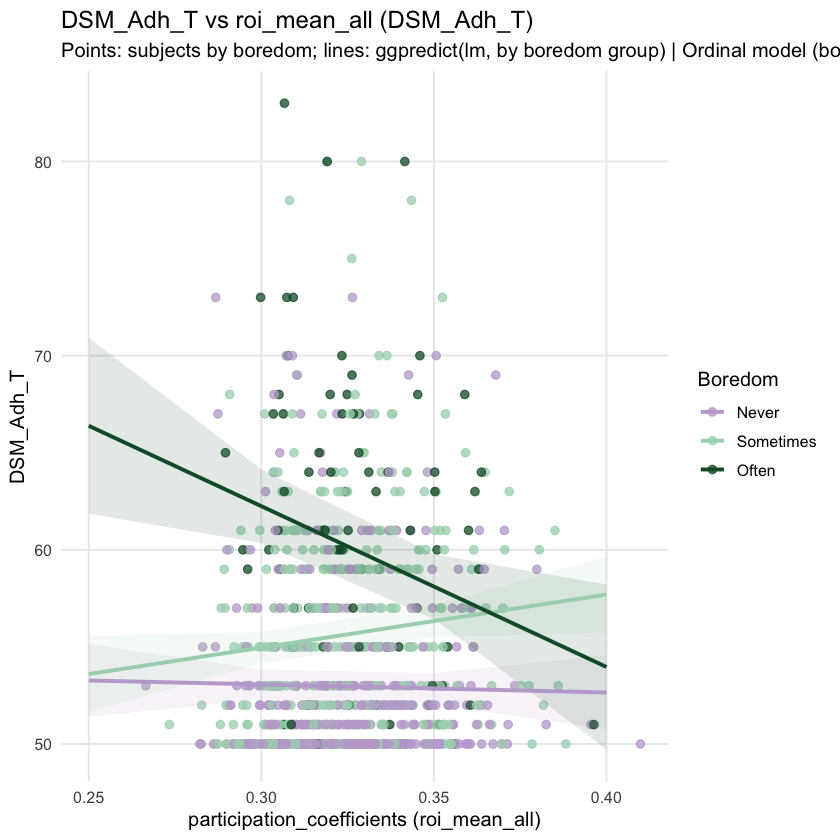

Saved 4a plot: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/figures/participation_coefficients/global_mean_ggpredict_behaviour/ggpredict_participation_coefficients_roi_mean_all_vs_ASR_Attn_T_by_boredom.svg 


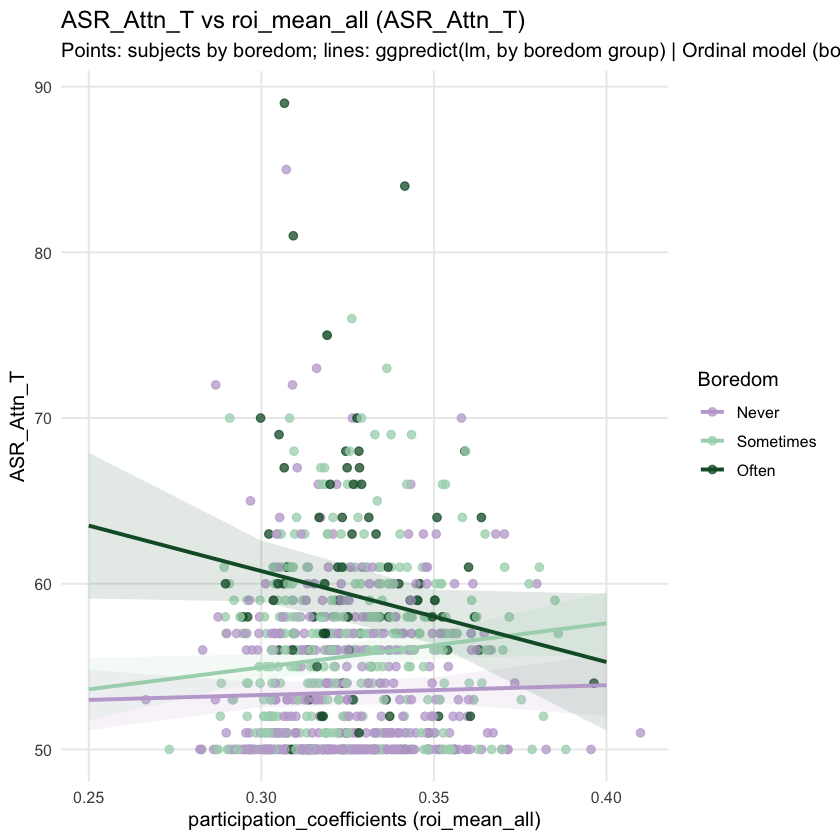

Saved 4a plot: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/figures/participation_coefficients/global_mean_ggpredict_behaviour/ggpredict_participation_coefficients_roi_mean_all_vs_DSM_Hype_Raw_by_boredom.svg 


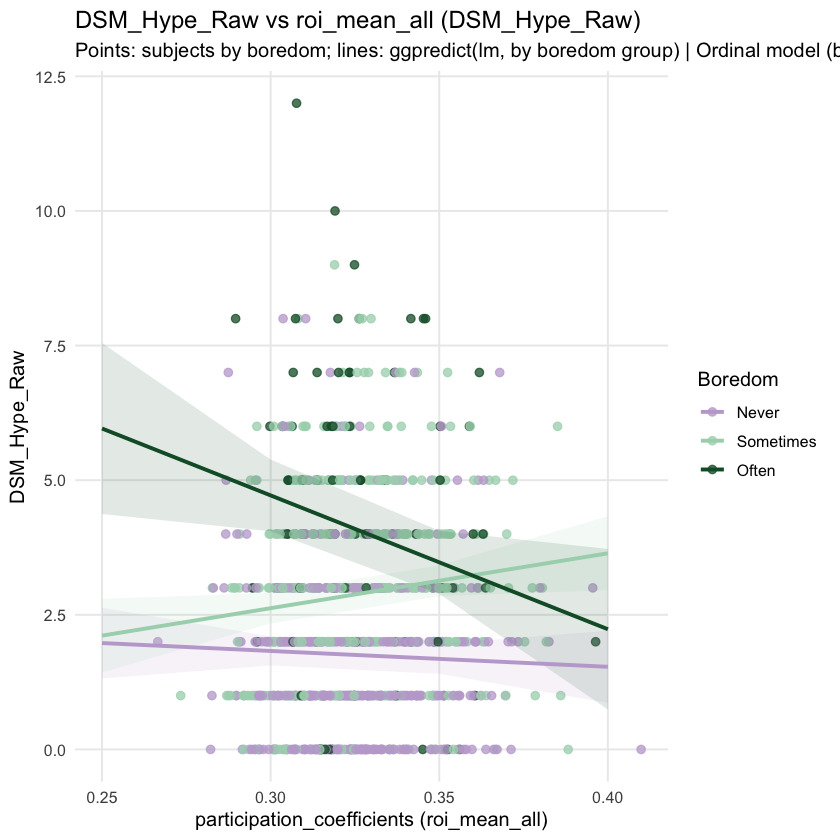

Saved 4a plot: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/figures/participation_coefficients/global_mean_ggpredict_behaviour/ggpredict_participation_coefficients_roi_mean_all_vs_age.y_by_boredom.svg 


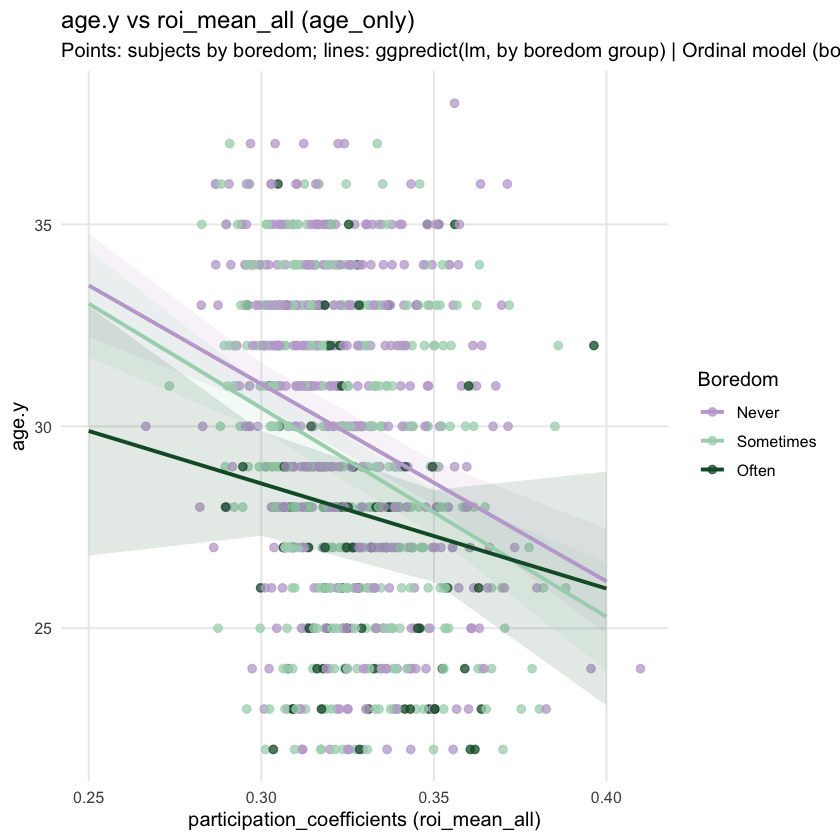

In [188]:
# =============================================================================
# 4a. Global mean vs behavioural scores: scatter + ggpredict by boredom
# =============================================================================

if (!requireNamespace("ggeffects", quietly = TRUE)) {
  stop(
    "Package 'ggeffects' is required for section 4a. Install with: install.packages('ggeffects')"
  )
}

if (!exists("model_data")) {
  stop("Run sections 1 and 3b first so model_data and global_model_results exist.")
}

if (!exists("age_covariate_name")) {
  age_covariate_name <- dplyr::case_when(
    "age" %in% names(model_data) ~ "age",
    "age.y" %in% names(model_data) ~ "age.y",
    "age.x" %in% names(model_data) ~ "age.x",
    TRUE ~ NA_character_
  )
}

if (!exists("boredom_palette")) {
  stop("Run section 0 (setup) first so boredom_palette is defined.")
}

global_4a_y_vars <- c(
  DSM_Adh_T = "DSM_Adh_T",
  ASR_Attn_T = "ASR_Attn_T",
  DSM_Hype_Raw = "DSM_Hype_Raw"
)
if (!is.na(age_covariate_name)) {
  global_4a_y_vars <- c(global_4a_y_vars, age_only = age_covariate_name)
}

fig_dir_4a <- file.path(
  paths$results_dir,
  "figures",
  sanitize_label(brain_measure_name),
  "global_mean_ggpredict_behaviour"
)
dir.create(fig_dir_4a, recursive = TRUE, showWarnings = FALSE)

plot_base_4a <- model_data %>%
  dplyr::select(
    subject_id,
    boredom,
    all_of(c(brain_global_var, unname(global_4a_y_vars)))
  ) %>%
  dplyr::filter(!is.na(boredom), !is.na(.data[[brain_global_var]])) %>%
  dplyr::mutate(
    boredom_grp = factor(
      boredom,
      levels = c(0, 1, 2),
      labels = names(boredom_palette)
    )
  )

x_label_4a <- paste0(brain_measure_name, " (", brain_global_var, ")")

for (model_name in names(global_4a_y_vars)) {
  y_var <- global_4a_y_vars[[model_name]]
  if (!y_var %in% names(plot_base_4a)) {
    warning("Skipping 4a plot for ", model_name, ": column ", y_var, " not found.")
    next
  }

  plot_df <- plot_base_4a %>%
    dplyr::filter(!is.na(.data[[y_var]]))

  if (nrow(plot_df) < 10) {
    warning("Skipping 4a plot for ", model_name, ": too few complete rows.")
    next
  }

  fml_lm <- stats::as.formula(
    paste(y_var, "~", brain_global_var, "* boredom_grp")
  )
  fit_lm <- stats::lm(fml_lm, data = plot_df)

  pred <- ggeffects::ggpredict(
    fit_lm,
    terms = c(brain_global_var, "boredom_grp")
  )
  pred_df <- as.data.frame(pred)

  ord_note <- ""
  if (exists("global_results_table")) {
    ord_row <- global_results_table %>%
      dplyr::filter(.data$model == model_name, .data$brain_var == brain_global_var) %>%
      dplyr::slice(1)
    if (nrow(ord_row) == 1 && !is.na(ord_row$p_value)) {
      ord_note <- paste0(
        "Ordinal model (boredom ~ ", brain_global_var, " + ", y_var,
        "): roi_mean_all p = ", signif(ord_row$p_value, 3)
      )
    }
  }

  p_4a <- ggplot2::ggplot() +
    ggplot2::geom_point(
      data = plot_df,
      ggplot2::aes(
        x = .data[[brain_global_var]],
        y = .data[[y_var]],
        color = boredom_grp
      ),
      alpha = 0.75,
      size = 2
    ) +
    ggplot2::geom_ribbon(
      data = pred_df,
      ggplot2::aes(
        x = x,
        ymin = conf.low,
        ymax = conf.high,
        fill = group
      ),
      alpha = 0.12,
      color = NA,
      show.legend = FALSE
    ) +
    ggplot2::geom_line(
      data = pred_df,
      ggplot2::aes(
        x = x,
        y = predicted,
        color = group
      ),
      linewidth = 1.1
    ) +
    ggplot2::scale_color_manual(values = boredom_palette, name = "Boredom") +
    ggplot2::scale_fill_manual(values = boredom_palette, guide = "none") +
    ggplot2::labs(
      x = x_label_4a,
      y = y_var,
      title = paste0(y_var, " vs ", brain_global_var, " (", model_name, ")"),
      subtitle = paste(
        c(
          "Points: subjects by boredom; lines: ggpredict(lm, by boredom group)",
          ord_note
        ),
        collapse = " | "
      )
    ) +
    ggplot2::theme_minimal(base_size = 12) +
    ggplot2::theme(panel.grid.minor = ggplot2::element_blank())

  print(p_4a)

  out_svg_4a <- file.path(
    fig_dir_4a,
    paste0(
      "ggpredict_",
      sanitize_label(brain_measure_name),
      "_",
      brain_global_var,
      "_vs_",
      y_var,
      "_by_boredom.svg"
    )
  )
  ggplot2::ggsave(out_svg_4a, plot = p_4a, width = 7.5, height = 5.5, dpi = 150)
  cat("Saved 4a plot:", out_svg_4a, "\n")
}


## 3c. Compare global mean model across conditions

Compare `roi_mean_all` models across:
- `DSM_Adh_T`
- `ASR_Attn_T`
- `DSM_Hype_Raw`
- `age_only`
- `no_covariates`

In [9]:
# Build a comparison table from 3b output (one row per model condition)
# Note: these p-values are uncorrected for global-mean comparisons.
global_conditions <- c("DSM_Adh_T", "ASR_Attn_T", "DSM_Hype_Raw", "age_only", "no_covariates")

if (!exists("global_results_table")) {
  stop("Run section 3b first so global_results_table is available.")
}

global_comparison_table <- global_results_table %>%
  filter(model %in% global_conditions) %>%
  mutate(
    odds_ratio = exp(estimate),
    ci_low = exp(estimate - 1.96 * std_error),
    ci_high = exp(estimate + 1.96 * std_error)
  ) %>%
  arrange(p_value) %>%
  dplyr::select(
    model,
    brain_var,
    estimate,
    std_error,
    t_value,
    p_value,
    odds_ratio,
    ci_low,
    ci_high,
    significant_fdr
  )

cat("\nGlobal-mean model comparison (ranked by p-value):\n")
print(global_comparison_table)

# Optional quick visual comparison of effect sizes
p_global_compare <- ggplot2::ggplot(
  global_comparison_table,
  ggplot2::aes(x = reorder(model, estimate), y = estimate)
) +
  ggplot2::geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  ggplot2::geom_pointrange(
    ggplot2::aes(ymin = estimate - 1.96 * std_error, ymax = estimate + 1.96 * std_error),
    color = "steelblue"
  ) +
  ggplot2::coord_flip() +
  ggplot2::labs(
    x = "Model condition",
    y = "Log-odds estimate for roi_mean_all",
    title = "Global mean model comparison across conditions"
  ) +
  ggplot2::theme_minimal(base_size = 12)

print(p_global_compare)

out_compare_csv <- file.path(
  paths$results_dir,
  paste0("ordinal_boredom_polr_", sanitize_label(brain_measure_name), "_roi_mean_global_comparison.csv")
)
readr::write_csv(global_comparison_table, out_compare_csv)
cat("\nSaved global comparison table:\n", out_compare_csv, "\n")

ERROR: Error: Run section 3b first so global_results_table is available.


## 3d. Plots of the raw data for behavioral metrics & global brain mean
Generate linear plots showing the raw values for global brain mean for each subject versus the behavioral variable, separate plot for each variable (DSM_Hype_Raw, ASR_Attn_T, DSM_Adh_T).
Plots colour subjects by boredom using `boredom_palette` from setup (Never `#C1AAD3`, Sometimes `#A8D5BA`, Often `#145A32`).


Saved: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/figures/participation_coefficients/raw_global_mean_behaviour/raw_participation_coefficients_roi_mean_all_vs_DSM_Adh_T_by_boredom.svg 


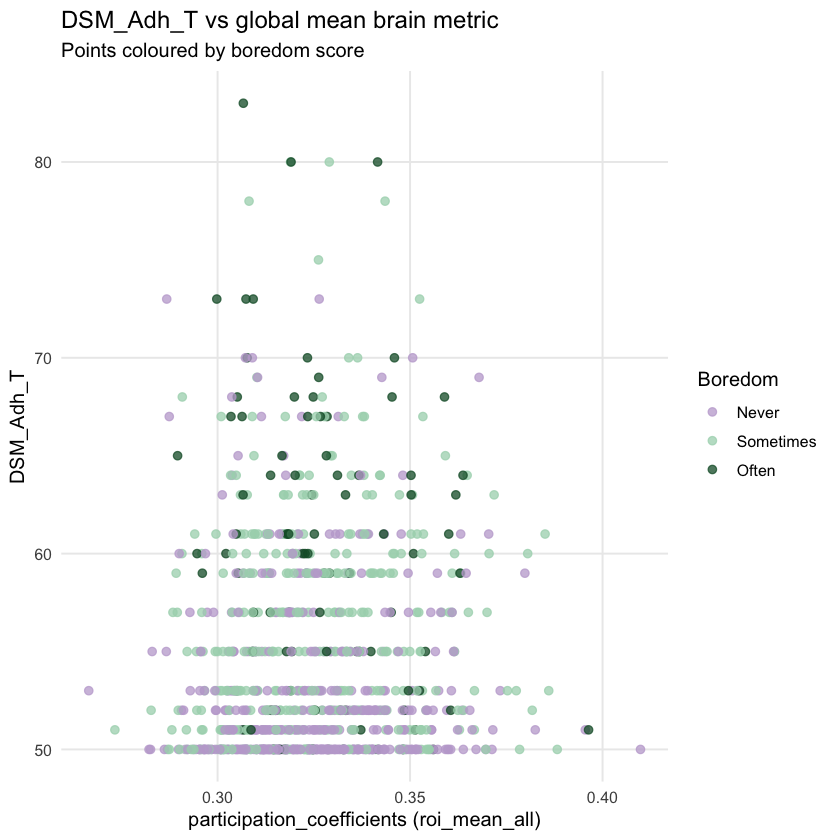

Saved: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/figures/participation_coefficients/raw_global_mean_behaviour/raw_participation_coefficients_roi_mean_all_vs_ASR_Attn_T_by_boredom.svg 


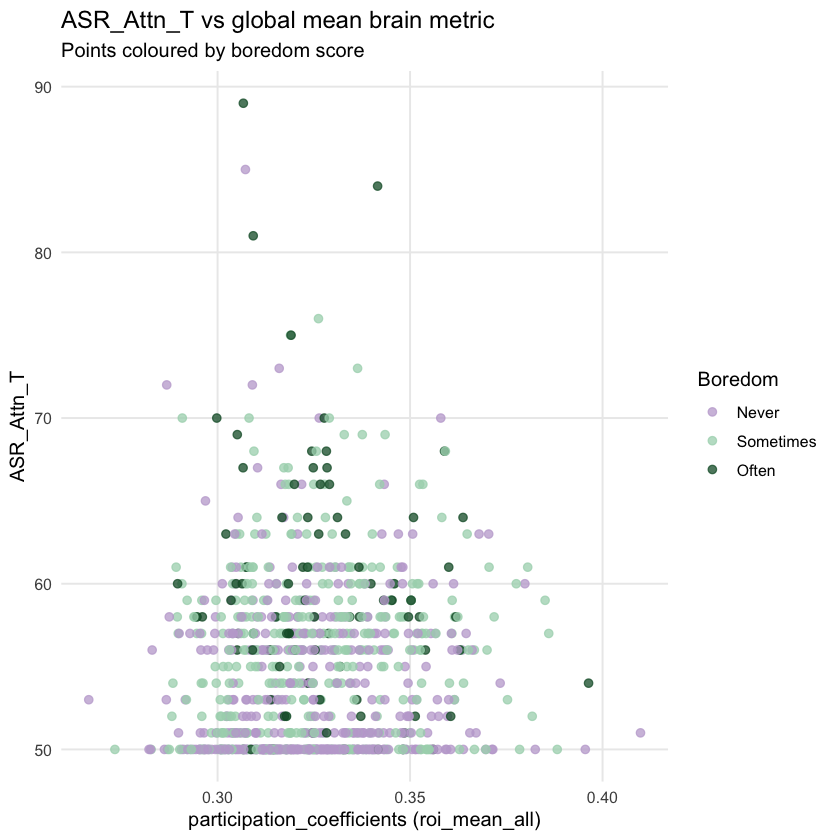

Saved: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/figures/participation_coefficients/raw_global_mean_behaviour/raw_participation_coefficients_roi_mean_all_vs_DSM_Hype_Raw_by_boredom.svg 


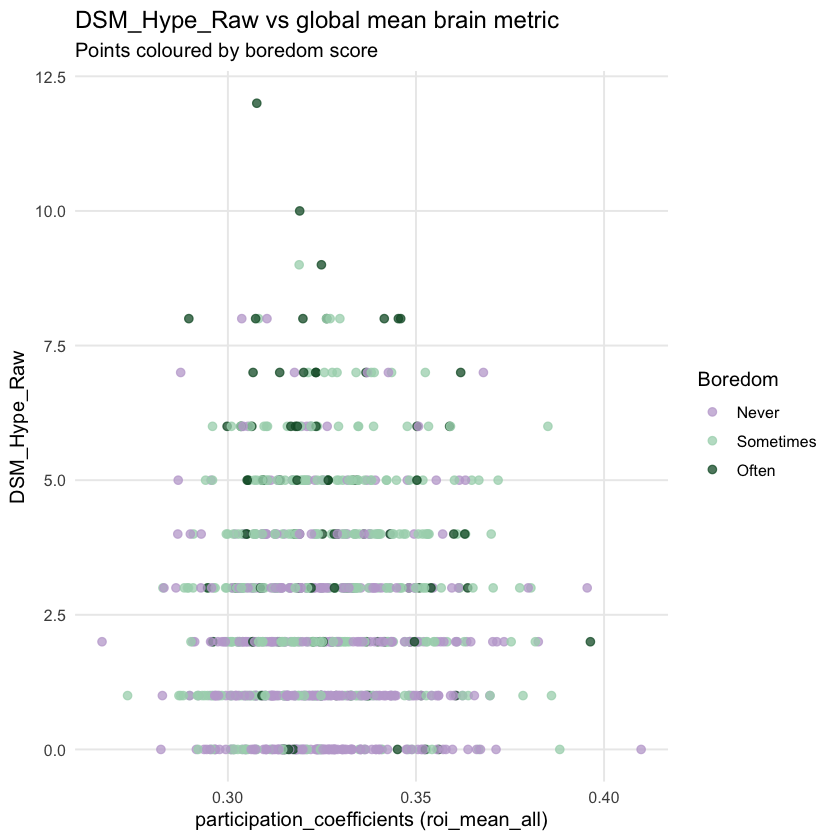

In [190]:
# =============================================================================
# 3d. Raw scatter plots: global brain mean vs behavioural variables (by boredom)
# =============================================================================

behaviour_plot_vars <- c("DSM_Adh_T", "ASR_Attn_T", "DSM_Hype_Raw")

if (!exists("boredom_palette")) {
  stop("Run section 0 (setup) first so boredom_palette is defined.")
}

raw_plot_data <- model_data %>%
  dplyr::select(subject_id, boredom, all_of(c(brain_global_var, behaviour_plot_vars))) %>%
  drop_na(boredom, all_of(brain_global_var)) %>%
  mutate(
    boredom_grp = factor(
      boredom,
      levels = c(0, 1, 2),
      labels = names(boredom_palette)
    )
  )

fig_dir_3d <- file.path(
  paths$results_dir,
  "figures",
  sanitize_label(brain_measure_name),
  "raw_global_mean_behaviour"
)
dir.create(fig_dir_3d, recursive = TRUE, showWarnings = FALSE)

x_label_3d <- paste0(brain_measure_name, " (", brain_global_var, ")")

for (behav_var in behaviour_plot_vars) {
  plot_df <- raw_plot_data %>%
    filter(!is.na(.data[[behav_var]]))

  p_raw <- ggplot2::ggplot(
    plot_df,
    ggplot2::aes(
      x = .data[[brain_global_var]],
      y = .data[[behav_var]],
      color = boredom_grp
    )
  ) +
    ggplot2::geom_point(alpha = 0.75, size = 2) +
    ggplot2::scale_color_manual(values = boredom_palette, name = "Boredom") +
    ggplot2::labs(
      x = x_label_3d,
      y = behav_var,
      title = paste0(behav_var, " vs global mean brain metric"),
      subtitle = "Points coloured by boredom score"
    ) +
    ggplot2::theme_minimal(base_size = 12) +
    ggplot2::theme(panel.grid.minor = ggplot2::element_blank())

  print(p_raw)

  out_png_3d <- file.path(
    fig_dir_3d,
    paste0(
      "raw_",
      sanitize_label(brain_measure_name),
      "_",
      brain_global_var,
      "_vs_",
      behav_var,
      "_by_boredom.svg"
    )
  )
  ggplot2::ggsave(out_png_3d, plot = p_raw, width = 7, height = 5.5, dpi = 150)
  cat("Saved:", out_png_3d, "\n")
}

## 5. Simple linear regression

Linear models predicting each behavioural covariate from brain metrics (separate model per outcome):

- `DSM_Adh_T ~ brain_metric` (502 ROIs + global mean)
- `ASR_Attn_T ~ brain_metric` (502 ROIs + global mean)
- `DSM_Hype_Raw ~ brain_metric` (502 ROIs + global mean)


### 5a. Per-ROI linear models (FDR across ROIs)


In [191]:
# =============================================================================
# 5. Simple linear regression: outcome ~ brain_metric
# =============================================================================

linear_outcomes <- c("boredom", "DSM_Adh_T", "ASR_Attn_T", "DSM_Hype_Raw")

run_lm_brain_batch <- function(
    outcome_var,
    data,
    brain_vars,
    analysis_scope = "per_roi",
    apply_fdr = TRUE
) {
  brain_vars <- as.character(brain_vars)
  preds <- unique(c(outcome_var, brain_vars, "subject_id"))
  missing_preds <- setdiff(preds, names(data))
  if (length(missing_preds) > 0) {
    stop("Missing columns for LM (", outcome_var, "): ", paste(missing_preds, collapse = ", "))
  }

  data_clean <- data %>%
    dplyr::select(all_of(preds)) %>%
    drop_na()

  cat("\n--- LM:", outcome_var, "~ brain |", analysis_scope, "---\n")
  cat("Brain predictor(s):", paste(brain_vars, collapse = ", "), "\n")
  cat("Final sample size:", nrow(data_clean), "\n")

  batch_results <- purrr::map_dfr(brain_vars, function(brain_var) {
    fml <- stats::as.formula(paste(outcome_var, "~", brain_var))
    fit <- tryCatch(
      stats::lm(fml, data = data_clean),
      error = function(e) {
        warning("LM failed for ", brain_var, ": ", conditionMessage(e))
        return(NULL)
      }
    )

    if (is.null(fit)) {
      return(tibble(
        brain_measure_name = brain_measure_name,
        outcome = outcome_var,
        analysis_scope = analysis_scope,
        brain_var = brain_var,
        term = brain_var,
        estimate = NA_real_,
        std_error = NA_real_,
        t_value = NA_real_,
        p_value = NA_real_
      ))
    }

    s <- summary(fit)$coefficients
    if (!brain_var %in% rownames(s)) {
      return(tibble(
        brain_measure_name = brain_measure_name,
        outcome = outcome_var,
        analysis_scope = analysis_scope,
        brain_var = brain_var,
        term = brain_var,
        estimate = NA_real_,
        std_error = NA_real_,
        t_value = NA_real_,
        p_value = NA_real_
      ))
    }

    tibble(
      brain_measure_name = brain_measure_name,
      outcome = outcome_var,
      analysis_scope = analysis_scope,
      brain_var = brain_var,
      term = brain_var,
      estimate = s[brain_var, "Estimate"],
      std_error = s[brain_var, "Std. Error"],
      t_value = s[brain_var, "t value"],
      p_value = s[brain_var, "Pr(>|t|)"]
    )
  })

  if (apply_fdr && nrow(batch_results) > 1) {
    batch_results <- batch_results %>%
      mutate(
        p_fdr = p.adjust(p_value, method = "fdr"),
        significant_fdr = !is.na(p_fdr) & p_fdr < fdr_alpha
      )
    cat("FDR-significant brain terms (q <", fdr_alpha, "):", sum(batch_results$significant_fdr, na.rm = TRUE), "\n")
  } else {
    batch_results <- batch_results %>%
      mutate(
        p_fdr = NA_real_,
        significant_fdr = !is.na(p_value) & p_value < fdr_alpha
      )
    cat("Uncorrected significant (p <", fdr_alpha, "):", sum(batch_results$significant_fdr, na.rm = TRUE), "\n")
  }

  batch_results
}

lm_roi_results <- list()

for (outcome_var in linear_outcomes) {
  lm_roi_results[[outcome_var]] <- run_lm_brain_batch(
    outcome_var = outcome_var,
    data = model_data,
    brain_vars = brain_predictors,
    analysis_scope = "per_roi",
    apply_fdr = TRUE
  )

  example_data <- model_data %>%
    dplyr::select(all_of(c(outcome_var, brain_predictors[[1]]))) %>%
    drop_na()
  example_fit <- stats::lm(
    stats::as.formula(paste(outcome_var, "~", brain_predictors[[1]])),
    data = example_data
  )
  cat("\nExample LM summary (", outcome_var, " ~ ", brain_predictors[[1]], "):\n", sep = "")
  print(summary(example_fit))
}

lm_roi_table <- dplyr::bind_rows(lm_roi_results)

out_lm_roi <- file.path(
  paths$results_dir,
  paste0("linear_", sanitize_label(brain_measure_name), "_502roi_fdr.csv")
)
readr::write_csv(lm_roi_table, out_lm_roi)
cat("\nSaved per-ROI linear results:\n ", normalizePath(out_lm_roi, winslash = "/"), "\n", sep = "")
cat("Rows saved:", nrow(lm_roi_table), "\n")



--- LM: boredom ~ brain | per_roi ---
Brain predictor(s): roi_1, roi_2, roi_3, roi_4, roi_5, roi_6, roi_7, roi_8, roi_9, roi_10, roi_11, roi_12, roi_13, roi_14, roi_15, roi_16, roi_17, roi_18, roi_19, roi_20, roi_21, roi_22, roi_23, roi_24, roi_25, roi_26, roi_27, roi_28, roi_29, roi_30, roi_31, roi_32, roi_33, roi_34, roi_35, roi_36, roi_37, roi_38, roi_39, roi_40, roi_41, roi_42, roi_43, roi_44, roi_45, roi_46, roi_47, roi_48, roi_49, roi_50, roi_51, roi_52, roi_53, roi_54, roi_55, roi_56, roi_57, roi_58, roi_59, roi_60, roi_61, roi_62, roi_63, roi_64, roi_65, roi_66, roi_67, roi_68, roi_69, roi_70, roi_71, roi_72, roi_73, roi_74, roi_75, roi_76, roi_77, roi_78, roi_79, roi_80, roi_81, roi_82, roi_83, roi_84, roi_85, roi_86, roi_87, roi_88, roi_89, roi_90, roi_91, roi_92, roi_93, roi_94, roi_95, roi_96, roi_97, roi_98, roi_99, roi_100, roi_101, roi_102, roi_103, roi_104, roi_105, roi_106, roi_107, roi_108, roi_109, roi_110, roi_111, roi_112, roi_113, roi_114, roi_115, roi_116, roi_1

### 5b. Global mean brain metric (`roi_mean_all`)


In [192]:
lm_global_results <- list()

for (outcome_var in linear_outcomes) {
  lm_global_results[[outcome_var]] <- run_lm_brain_batch(
    outcome_var = outcome_var,
    data = model_data,
    brain_vars = brain_global_var,
    analysis_scope = "roi_mean_global",
    apply_fdr = FALSE
  )

  example_data <- model_data %>%
    dplyr::select(all_of(c(outcome_var, brain_global_var))) %>%
    drop_na()
  example_fit <- stats::lm(
    stats::as.formula(paste(outcome_var, "~", brain_global_var)),
    data = example_data
  )
  cat("\nGlobal mean LM summary (", outcome_var, " ~ ", brain_global_var, "):\n", sep = "")
  print(summary(example_fit))
}

lm_global_table <- dplyr::bind_rows(lm_global_results)

out_lm_global <- file.path(
  paths$results_dir,
  paste0("linear_", sanitize_label(brain_measure_name), "_roi_mean_global.csv")
)
readr::write_csv(lm_global_table, out_lm_global)
cat("\nSaved global-mean linear results:\n ", normalizePath(out_lm_global, winslash = "/"), "\n", sep = "")
print(lm_global_table)



--- LM: boredom ~ brain | roi_mean_global ---
Brain predictor(s): roi_mean_all 
Final sample size: 938 
Uncorrected significant (p < 0.05 ): 0 

Global mean LM summary (boredom ~ roi_mean_all):

Call:
stats::lm(formula = stats::as.formula(paste(outcome_var, "~", 
    brain_global_var)), data = example_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.7196 -0.6100  0.3369  0.3978  1.4296 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)
(Intercept)    0.2110     0.3457   0.610    0.542
roi_mean_all   1.2410     1.0623   1.168    0.243

Residual standard error: 0.6567 on 936 degrees of freedom
Multiple R-squared:  0.001456,	Adjusted R-squared:  0.0003892 
F-statistic: 1.365 on 1 and 936 DF,  p-value: 0.243


--- LM: DSM_Adh_T ~ brain | roi_mean_global ---
Brain predictor(s): roi_mean_all 
Final sample size: 939 
Uncorrected significant (p < 0.05 ): 0 

Global mean LM summary (DSM_Adh_T ~ roi_mean_all):

Call:
stats::lm(formula = stats::as.formula(paste(outcom

## 6. Linear regression plots (global mean: `roi_mean_all`)

Scatter plots with linear fit for each outcome ~ `roi_mean_all`, points coloured by boredom (same palette as section 3d). Annotations show R-squared and **uncorrected (raw) p-value** for the brain slope (not FDR-corrected).


In [11]:
# =============================================================================
# 6. Plots: linear relationship (5b global mean models)
# =============================================================================

if (!exists("boredom_palette")) {
  stop("Run section 0 (setup) first so boredom_palette is defined.")
}

lm_plot_base <- model_data %>%
  dplyr::select(subject_id, boredom, all_of(c(linear_outcomes, brain_global_var))) %>%
  drop_na(boredom, all_of(brain_global_var)) %>%
  mutate(
    boredom_grp = factor(
      boredom,
      levels = c(0, 1, 2),
      labels = names(boredom_palette)
    )
  )

fig_dir_lm <- file.path(
  paths$results_dir,
  "figures",
  sanitize_label(brain_measure_name),
  "linear_global_mean"
)
dir.create(fig_dir_lm, recursive = TRUE, showWarnings = FALSE)

x_label <- paste0(brain_measure_name, " (", brain_global_var, ")")

for (outcome_var in linear_outcomes) {
  plot_df <- lm_plot_base %>%
    filter(!is.na(.data[[outcome_var]]))

  fit <- stats::lm(
    stats::as.formula(paste(outcome_var, "~", brain_global_var)),
    data = plot_df
  )
  s <- summary(fit)
  raw_p <- coef(s)[brain_global_var, "Pr(>|t|)"]

  stat_label <- paste0(
    "R\u00b2 = ", signif(s$r.squared, 3),
    "\np (raw) = ", signif(raw_p, 3)
  )

  p_lm <- ggplot2::ggplot(
    plot_df,
    ggplot2::aes(
      x = .data[[brain_global_var]],
      y = .data[[outcome_var]],
      color = boredom_grp
    )
  ) +
    ggplot2::geom_point(alpha = 0.75, size = 2) +
    ggplot2::geom_smooth(
      method = "lm",
      se = FALSE,
      color = "grey60",
      linewidth = 1.6,
      inherit.aes = FALSE,
      mapping = ggplot2::aes(
        x = .data[[brain_global_var]],
        y = .data[[outcome_var]]
      )
    ) +
    ggplot2::geom_smooth(
      method = "lm",
      se = TRUE,
      fill = "grey85",
      color = "black",
      linewidth = 0.9,
      inherit.aes = FALSE,
      mapping = ggplot2::aes(
        x = .data[[brain_global_var]],
        y = .data[[outcome_var]]
      )
    ) +
    ggplot2::annotate(
      "text",
      x = Inf,
      y = Inf,
      label = stat_label,
      hjust = 1.05,
      vjust = 1.1,
      size = 3.5
    ) +
    ggplot2::scale_color_manual(values = boredom_palette, name = "Boredom") +
    ggplot2::labs(
      x = x_label,
      y = outcome_var,
      title = paste0(outcome_var, " ~ ", brain_global_var),
      subtitle = "LM line: black (grey outline); p-value is uncorrected"
    ) +
    ggplot2::theme_minimal(base_size = 12) +
    ggplot2::theme(panel.grid.minor = ggplot2::element_blank()) +
    ggplot2::coord_cartesian(clip = "off")

  print(p_lm)

  out_lm_svg <- file.path(
    fig_dir_lm,
    paste0(
      "linear_",
      sanitize_label(brain_measure_name),
      "_",
      brain_global_var,
      "_vs_",
      outcome_var,
      "_by_boredom.svg"
    )
  )
  ggplot2::ggsave(out_lm_svg, plot = p_lm, width = 7, height = 5.5)
  cat("Saved:", out_lm_svg, "\n")
}


ERROR: [1m[33mError[39m in `dplyr::select()`:[22m
[1m[22m[36mi[39m In argument: `all_of(c(linear_outcomes, brain_global_var))`.
[1mCaused by error:[22m
[33m![39m object 'linear_outcomes' not found


## 7. Spearman rank correlation

Spearman correlation between outcomes (`boredom`, behavioural scores) and brain metrics:

- `DSM_Adh_T`, `ASR_Attn_T`, `DSM_Hype_Raw` vs all 502 ROIs (FDR across ROIs per outcome)
- Same outcomes vs global mean (`roi_mean_all`)

Plots (global mean only): scatter with boredom-coloured points and Spearman trend line (LM on ranked values).


--- Spearman (per ROI): boredom ---
FDR-significant (q < 0.05 ): 0 

--- Spearman (per ROI): DSM_Adh_T ---
FDR-significant (q < 0.05 ): 237 

--- Spearman (per ROI): ASR_Attn_T ---
FDR-significant (q < 0.05 ): 184 

--- Spearman (per ROI): DSM_Hype_Raw ---
FDR-significant (q < 0.05 ): 0 

Saved per-ROI Spearman results:
 /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/spearman_functional_connectivity_502roi_fdr.csv 

--- Spearman (global mean): boredom ---
# A tibble: 1 x 8
  brain_measure_name      outcome analysis_scope  brain_var    rho p_value p_fdr
  <chr>                   <chr>   <chr>           <chr>      <dbl>   <dbl> <dbl>
1 functional_connectivity boredom roi_mean_global roi_mean~ 0.0359   0.271    NA
# i 1 more variable: significant_fdr <lgl>

--- Spearman (global mean): DSM_Adh_T ---
# A tibble: 1 x 8
  brain_measure_name      outcome  analysis_scope brain_var    rho p_value p_fdr


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


Saved: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/figures/functional_connectivity/spearman_global_mean/spearman_functional_connectivity_roi_mean_all_vs_boredom_boredom_score.svg 


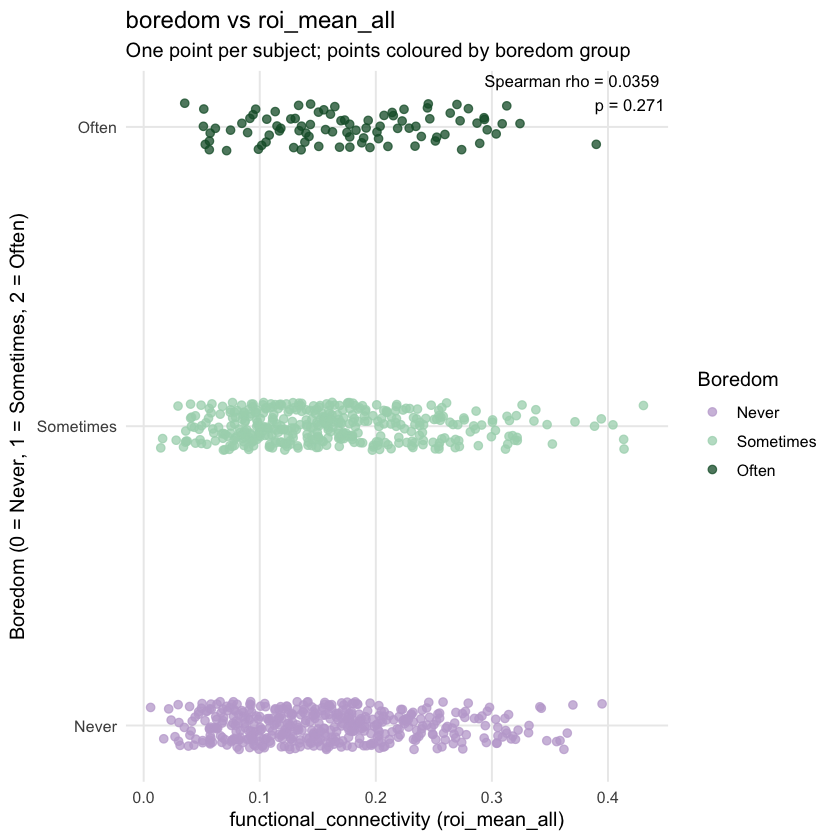

Saved: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/figures/functional_connectivity/spearman_global_mean/spearman_functional_connectivity_roi_mean_all_vs_DSM_Adh_T_by_boredom.svg 


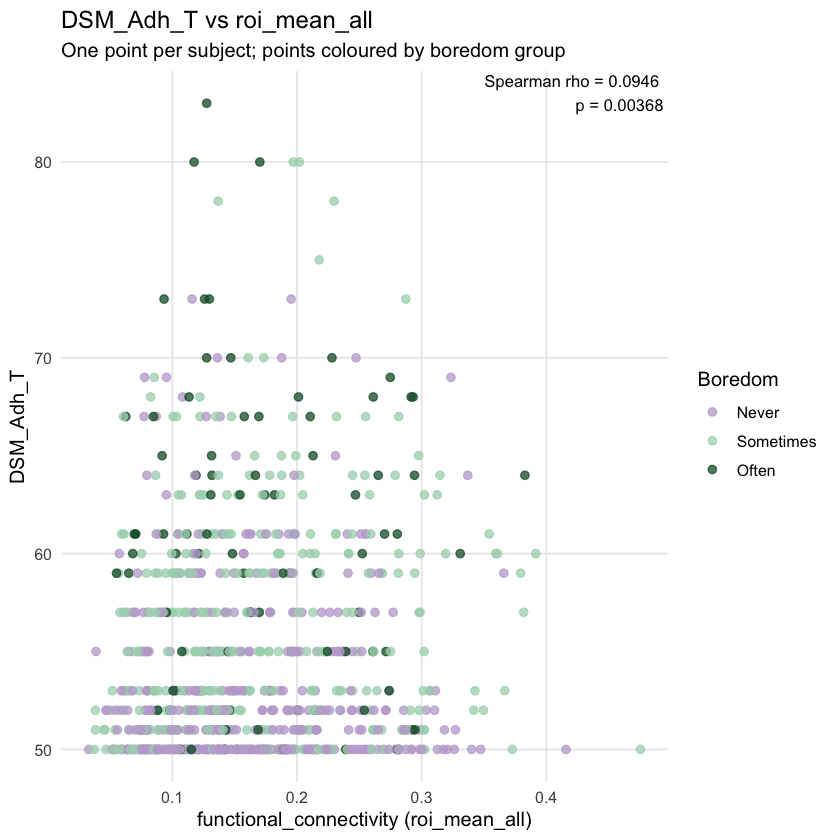

Saved: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/figures/functional_connectivity/spearman_global_mean/spearman_functional_connectivity_roi_mean_all_vs_ASR_Attn_T_by_boredom.svg 


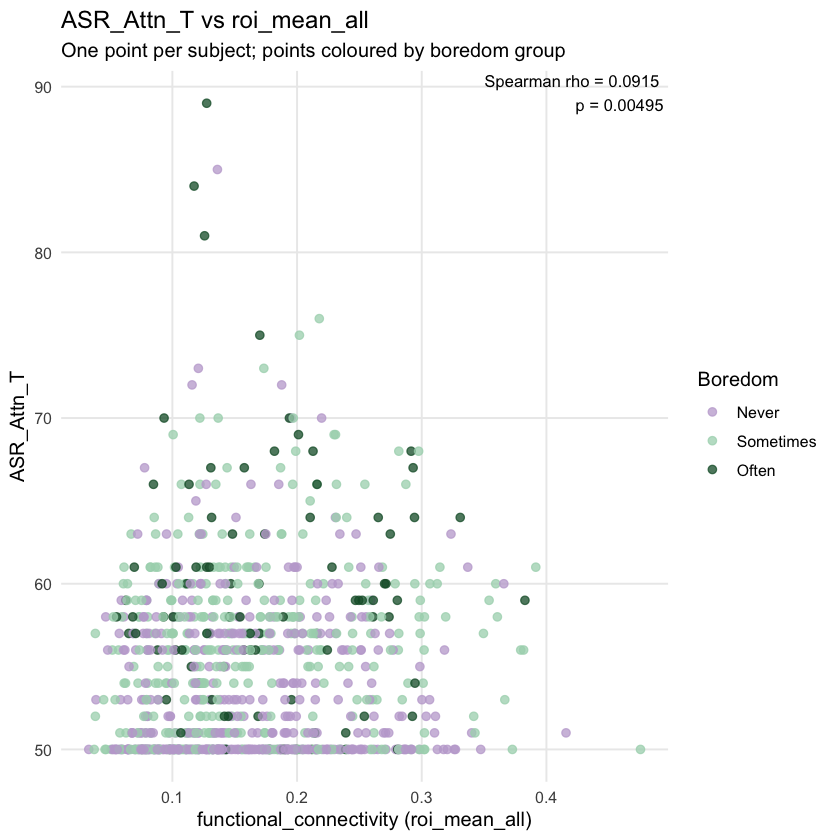

Saved: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/figures/functional_connectivity/spearman_global_mean/spearman_functional_connectivity_roi_mean_all_vs_DSM_Hype_Raw_by_boredom.svg 


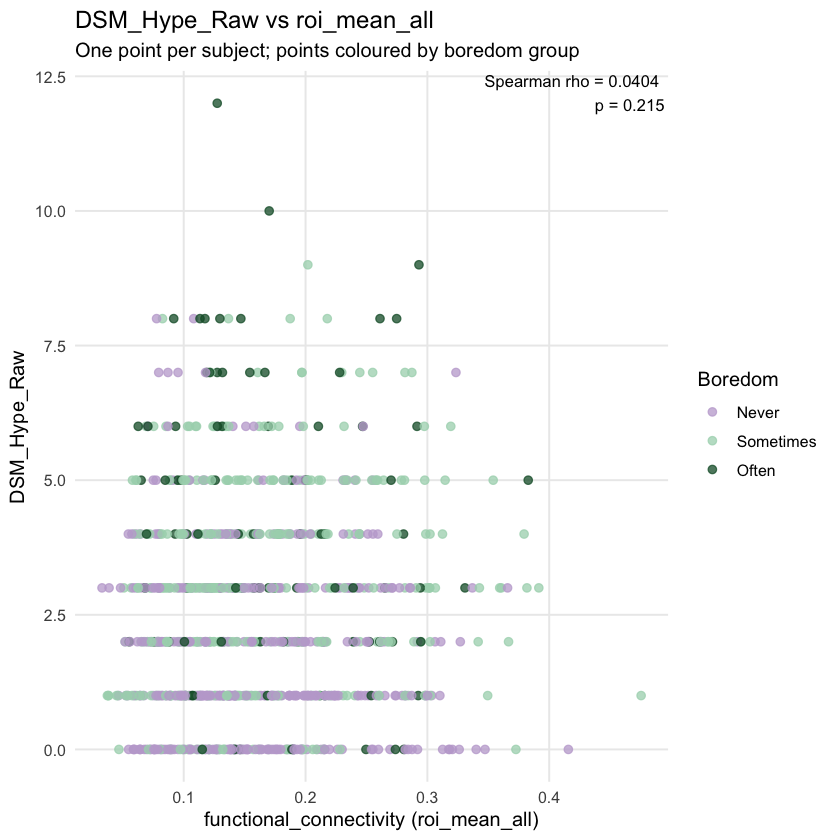

In [18]:
# =============================================================================
# 7. Spearman rank correlation: boredom + behavioural outcomes vs brain metrics
# =============================================================================

spearman_outcomes <- c(
  "boredom",
  "DSM_Adh_T",
  "ASR_Attn_T",
  "DSM_Hype_Raw"
)

if (!exists("boredom_palette")) {
  stop("Run section 0 (setup) first so boredom_palette is defined.")
}

run_spearman_batch <- function(
    outcome_var,
    data,
    brain_vars,
    analysis_scope = "per_roi",
    apply_fdr = TRUE
) {
  brain_vars <- as.character(brain_vars)

  batch_results <- purrr::map_dfr(brain_vars, function(brain_var) {
    d <- data %>%
      dplyr::select(all_of(c(outcome_var, brain_var))) %>%
      drop_na()

    if (nrow(d) < 3) {
      return(tibble(
        brain_measure_name = brain_measure_name,
        outcome = outcome_var,
        analysis_scope = analysis_scope,
        brain_var = brain_var,
        rho = NA_real_,
        p_value = NA_real_
      ))
    }

    ct <- stats::cor.test(
      d[[brain_var]],
      d[[outcome_var]],
      method = "spearman",
      exact = FALSE
    )

    tibble(
      brain_measure_name = brain_measure_name,
      outcome = outcome_var,
      analysis_scope = analysis_scope,
      brain_var = brain_var,
      rho = unname(ct$estimate),
      p_value = ct$p.value
    )
  })

  if (apply_fdr && nrow(batch_results) > 1) {
    batch_results <- batch_results %>%
      mutate(
        p_fdr = p.adjust(p_value, method = "fdr"),
        significant_fdr = !is.na(p_fdr) & p_fdr < fdr_alpha
      )
  } else {
    batch_results <- batch_results %>%
      mutate(
        p_fdr = NA_real_,
        significant_fdr = !is.na(p_value) & p_value < fdr_alpha
      )
  }

  batch_results
}

# --- 7a. Per-ROI Spearman (502 ROIs) ---
spearman_roi_table <- purrr::map_dfr(spearman_outcomes, function(outcome_var) {
  cat("\n--- Spearman (per ROI):", outcome_var, "---\n")
  res <- run_spearman_batch(
    outcome_var = outcome_var,
    data = model_data,
    brain_vars = brain_predictors,
    analysis_scope = "per_roi",
    apply_fdr = TRUE
  )
  cat("FDR-significant (q <", fdr_alpha, "):", sum(res$significant_fdr, na.rm = TRUE), "\n")
  res
})

out_spearman_roi <- file.path(
  paths$results_dir,
  paste0("spearman_", sanitize_label(brain_measure_name), "_502roi_fdr.csv")
)
readr::write_csv(spearman_roi_table, out_spearman_roi)
cat("\nSaved per-ROI Spearman results:\n", out_spearman_roi, "\n")

# --- 7b. Global mean Spearman ---
spearman_global_results <- purrr::map_dfr(spearman_outcomes, function(outcome_var) {
  cat("\n--- Spearman (global mean):", outcome_var, "---\n")
  res <- run_spearman_batch(
    outcome_var = outcome_var,
    data = model_data,
    brain_vars = brain_global_var,
    analysis_scope = "roi_mean_global",
    apply_fdr = FALSE
  )
  print(res)
  res
})

spearman_global_table <- dplyr::bind_rows(spearman_global_results)

out_spearman_global <- file.path(
  paths$results_dir,
  paste0("spearman_", sanitize_label(brain_measure_name), "_roi_mean_global.csv")
)
readr::write_csv(spearman_global_table, out_spearman_global)
cat("\nSaved global-mean Spearman results:\n", out_spearman_global, "\n")

# --- 7c. Global mean plots (raw values + Spearman rho) ---
spearman_plot_base <- model_data %>%
  dplyr::select(subject_id, boredom, all_of(c(spearman_outcomes, brain_global_var))) %>%
  drop_na(boredom, all_of(brain_global_var)) %>%
  mutate(
    boredom_grp = factor(
      boredom,
      levels = c(0, 1, 2),
      labels = names(boredom_palette)
    )
  )

fig_dir_spearman <- file.path(
  paths$results_dir,
  "figures",
  sanitize_label(brain_measure_name),
  "spearman_global_mean"
)
dir.create(fig_dir_spearman, recursive = TRUE, showWarnings = FALSE)

x_label_spearman <- paste0(brain_measure_name, " (", brain_global_var, ")")
y_labels_spearman <- c(
  boredom = "Boredom (0 = Never, 1 = Sometimes, 2 = Often)",
  DSM_Adh_T = "DSM_Adh_T",
  ASR_Attn_T = "ASR_Attn_T",
  DSM_Hype_Raw = "DSM_Hype_Raw"
)

for (outcome_var in spearman_outcomes) {
  if (!outcome_var %in% names(y_labels_spearman)) {
    stop("Add a y-axis label for outcome: ", outcome_var)
  }

  plot_df <- spearman_plot_base %>%
    dplyr::filter(!is.na(.data[[outcome_var]]))

  ct <- stats::cor.test(
    plot_df[[brain_global_var]],
    plot_df[[outcome_var]],
    method = "spearman",
    exact = FALSE
  )

  stat_label <- paste0(
    "Spearman rho = ", signif(unname(ct$estimate), 3),
    "\np = ", signif(ct$p.value, 3)
  )

  p_spearman <- ggplot2::ggplot(
    plot_df,
    ggplot2::aes(
      x = .data[[brain_global_var]],
      y = .data[[outcome_var]],
      color = boredom_grp
    )
  )

  if (outcome_var == "boredom") {
    p_spearman <- p_spearman +
      ggplot2::geom_jitter(width = 0.05, height = 0.08, alpha = 0.75, size = 2)
  } else {
    p_spearman <- p_spearman +
      ggplot2::geom_point(alpha = 0.75, size = 2)
  }

  p_spearman <- p_spearman +
    ggplot2::annotate(
      "text",
      x = Inf,
      y = Inf,
      label = stat_label,
      hjust = 1.05,
      vjust = 1.1,
      size = 3.5
    ) +
    ggplot2::scale_color_manual(values = boredom_palette, name = "Boredom") +
    ggplot2::scale_x_continuous(name = x_label_spearman) +
    ggplot2::scale_y_continuous(name = y_labels_spearman[[outcome_var]]) +
    ggplot2::labs(
      title = paste0(outcome_var, " vs ", brain_global_var),
      subtitle = "One point per subject; points coloured by boredom group"
    ) +
    ggplot2::theme_minimal(base_size = 12) +
    ggplot2::theme(panel.grid.minor = ggplot2::element_blank()) +
    ggplot2::coord_cartesian(clip = "off")

  if (outcome_var == "boredom") {
    p_spearman <- p_spearman +
      ggplot2::scale_y_continuous(
        name = y_labels_spearman[[outcome_var]],
        breaks = c(0, 1, 2),
        labels = names(boredom_palette)
      )
  }

  print(p_spearman)

  plot_suffix <- if (outcome_var == "boredom") "_boredom_score" else "_by_boredom"
  out_spearman_svg <- file.path(
    fig_dir_spearman,
    paste0(
      "spearman_",
      sanitize_label(brain_measure_name),
      "_",
      brain_global_var,
      "_vs_",
      outcome_var,
      plot_suffix,
      ".svg"
    )
  )
  ggplot2::ggsave(out_spearman_svg, plot = p_spearman, width = 7, height = 5.5)
  cat("Saved:", out_spearman_svg, "\n")
}

## 8. Behavioural scores vs boredom group

Spearman correlation (boredom 0/1/2 vs each behavioural score), Kruskal–Wallis across boredom groups, and violin plots with raw subject values grouped by Never / Sometimes / Often.

Section 8 sample size: 938 subjects
Boredom counts:

    Never Sometimes     Often 
      453       394        91 

Behaviour vs boredom <U+2014> correlation and group tests (alpha = 0.05 ):
# A tibble: 3 x 10
  behavioural_var     n spearman_rho spearman_p pearson_r pearson_p
  <chr>           <int>        <dbl>      <dbl>     <dbl>     <dbl>
1 DSM_Adh_T         938        0.367   2.91e-31     0.369  1.48e-31
2 ASR_Attn_T        938        0.319   1.30e-23     0.321  7.40e-24
3 DSM_Hype_Raw      938        0.360   4.52e-30     0.372  3.13e-32
# i 4 more variables: kruskal_wallis_chi2 <dbl>, kruskal_wallis_p <dbl>,
#   spearman_significant <lgl>, kw_significant <lgl>

Saved stats table:
/Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/behaviour_boredom_association_participation_coefficients.csv
Saved: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Dancke

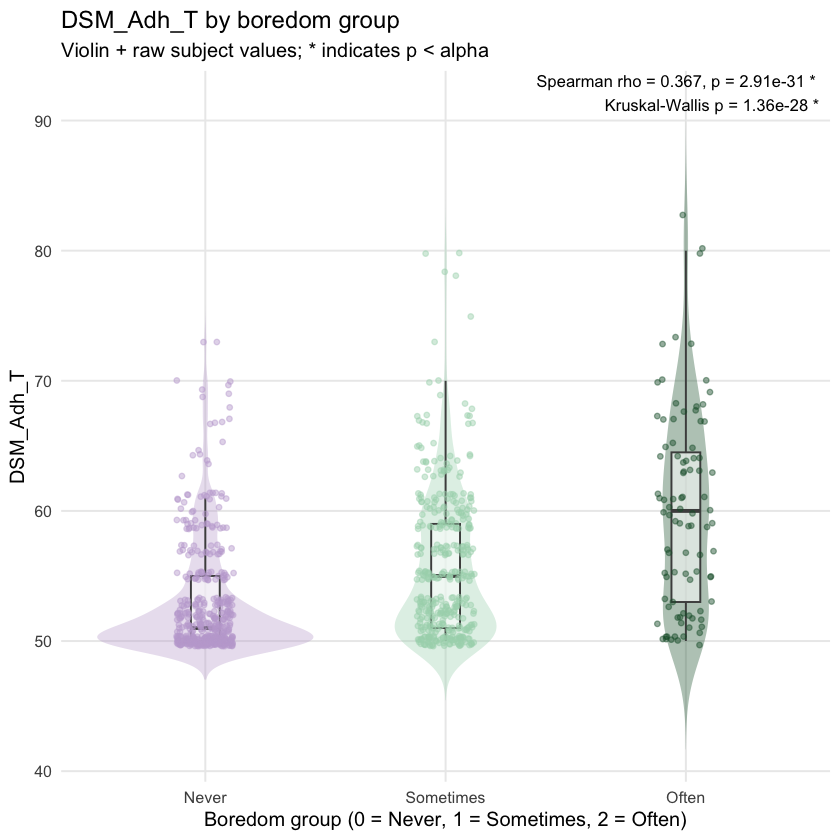

Saved: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/figures/behaviour_boredom/participation_coefficients/violin_ASR_Attn_T_by_boredom.svg 


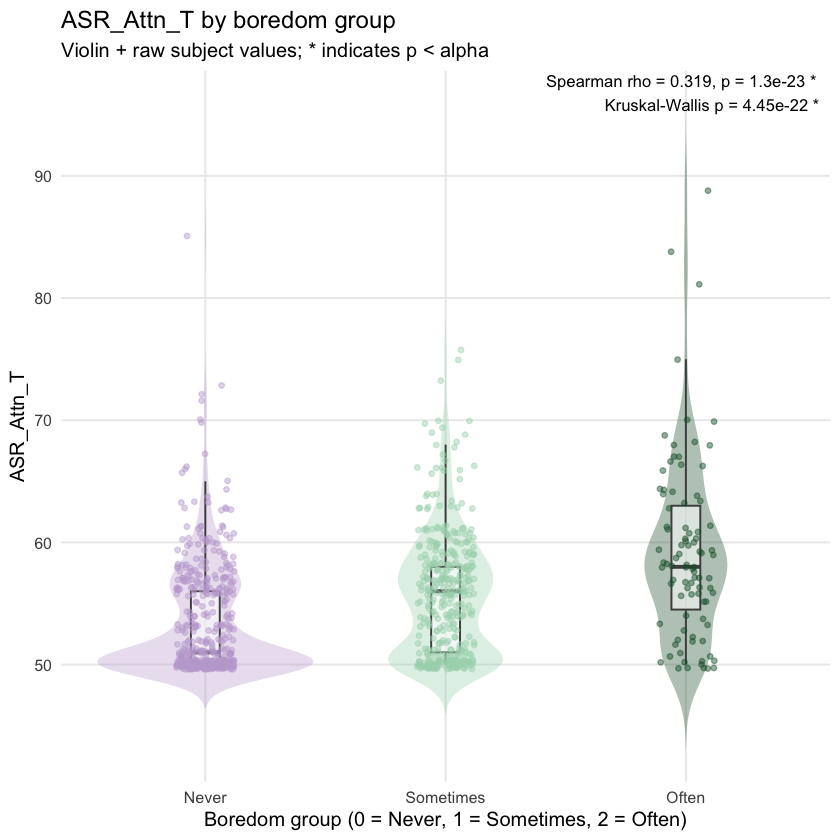

Saved: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/figures/behaviour_boredom/participation_coefficients/violin_DSM_Hype_Raw_by_boredom.svg 


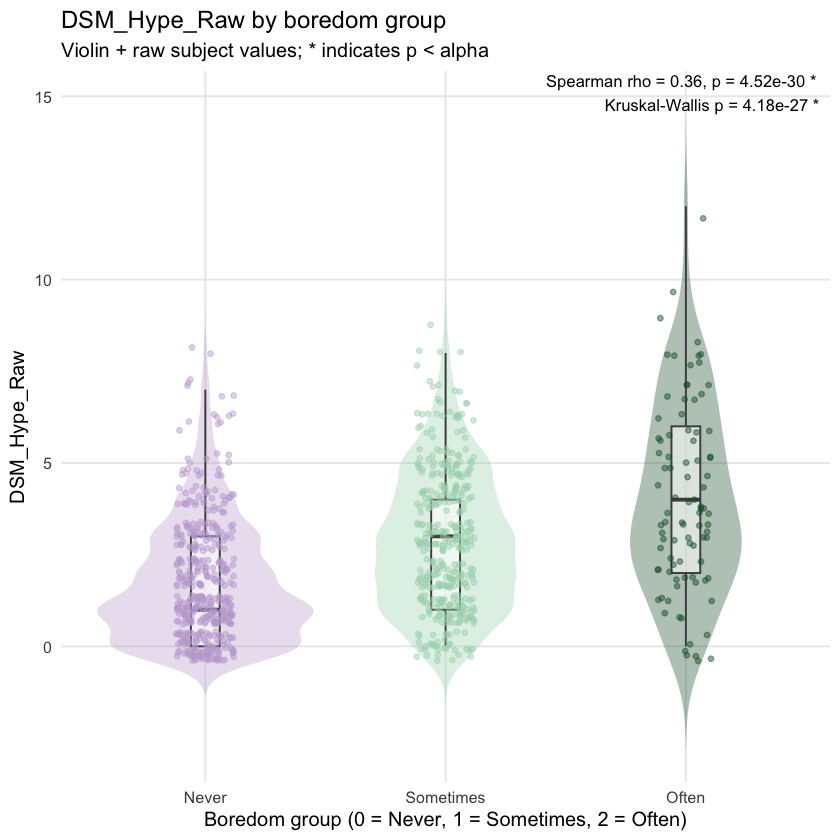

In [82]:
# =============================================================================
# 8. Behavioural scores vs boredom group (correlation + violin plots)
# =============================================================================

if (!exists("model_data")) {
  stop("Run sections 1–2 first so model_data is available.")
}
if (!exists("boredom_palette")) {
  stop("Run section 0 (setup) first so boredom_palette is defined.")
}

behaviour_boredom_vars <- c("DSM_Adh_T", "ASR_Attn_T", "DSM_Hype_Raw")
missing_behav <- setdiff(behaviour_boredom_vars, names(model_data))
if (length(missing_behav) > 0) {
  stop("Missing behavioural columns in model_data: ", paste(missing_behav, collapse = ", "))
}

behav_boredom_data <- model_data %>%
  dplyr::select(subject_id, boredom, all_of(behaviour_boredom_vars)) %>%
  dplyr::filter(!is.na(boredom)) %>%
  dplyr::mutate(
    boredom_grp = factor(
      boredom,
      levels = c(0, 1, 2),
      labels = names(boredom_palette)
    )
  )

cat("Section 8 sample size:", nrow(behav_boredom_data), "subjects\n")
cat("Boredom counts:\n")
print(table(behav_boredom_data$boredom_grp, useNA = "ifany"))

behav_boredom_stats <- purrr::map_dfr(behaviour_boredom_vars, function(behav_var) {
  d <- behav_boredom_data %>%
    dplyr::filter(!is.na(.data[[behav_var]]))

  ct_spearman <- stats::cor.test(
    d$boredom,
    d[[behav_var]],
    method = "spearman",
    exact = FALSE
  )
  ct_pearson <- stats::cor.test(d$boredom, d[[behav_var]], method = "pearson")
  kw <- stats::kruskal.test(d[[behav_var]] ~ d$boredom_grp)

  tibble::tibble(
    behavioural_var = behav_var,
    n = nrow(d),
    spearman_rho = unname(ct_spearman$estimate),
    spearman_p = ct_spearman$p.value,
    pearson_r = unname(ct_pearson$estimate),
    pearson_p = ct_pearson$p.value,
    kruskal_wallis_chi2 = unname(kw$statistic),
    kruskal_wallis_p = kw$p.value,
    spearman_significant = spearman_p < fdr_alpha,
    kw_significant = kruskal_wallis_p < fdr_alpha
  )
})

cat("\nBehaviour vs boredom — correlation and group tests (alpha =", fdr_alpha, "):\n")
print(behav_boredom_stats)

out_csv_behav_boredom <- file.path(
  paths$results_dir,
  paste0("behaviour_boredom_association_", sanitize_label(brain_measure_name), ".csv")
)
readr::write_csv(behav_boredom_stats, out_csv_behav_boredom)
cat("\nSaved stats table:\n", out_csv_behav_boredom, "\n", sep = "")

fig_dir_behav_boredom <- file.path(
  paths$results_dir,
  "figures",
  "behaviour_boredom",
  sanitize_label(brain_measure_name)
)
dir.create(fig_dir_behav_boredom, recursive = TRUE, showWarnings = FALSE)

for (behav_var in behaviour_boredom_vars) {
  plot_df <- behav_boredom_data %>%
    dplyr::filter(!is.na(.data[[behav_var]]))

  stat_row <- behav_boredom_stats %>%
    dplyr::filter(.data$behavioural_var == behav_var) %>%
    dplyr::slice(1)

  stat_label <- paste0(
    "Spearman rho = ", signif(stat_row$spearman_rho, 3),
    ", p = ", signif(stat_row$spearman_p, 3),
    ifelse(stat_row$spearman_significant, " *", ""),
    "\nKruskal-Wallis p = ", signif(stat_row$kruskal_wallis_p, 3),
    ifelse(stat_row$kw_significant, " *", "")
  )

  p_violin <- ggplot2::ggplot(
    plot_df,
    ggplot2::aes(
      x = boredom_grp,
      y = .data[[behav_var]],
      fill = boredom_grp,
      color = boredom_grp
    )
  ) +
    ggplot2::geom_violin(trim = FALSE, alpha = 0.35, color = NA) +
    ggplot2::geom_boxplot(
      width = 0.12,
      outlier.shape = NA,
      alpha = 0.55,
      fill = "white",
      color = "grey30"
    ) +
    ggplot2::geom_jitter(
      width = 0.12,
      alpha = 0.45,
      size = 1.2,
      show.legend = FALSE
    ) +
    ggplot2::scale_fill_manual(values = boredom_palette, name = "Boredom") +
    ggplot2::scale_color_manual(values = boredom_palette, guide = "none") +
    ggplot2::annotate(
      "text",
      x = Inf,
      y = Inf,
      label = stat_label,
      hjust = 1.05,
      vjust = 1.1,
      size = 3.5
    ) +
    ggplot2::labs(
      x = "Boredom group (0 = Never, 1 = Sometimes, 2 = Often)",
      y = behav_var,
      title = paste0(behav_var, " by boredom group"),
      subtitle = "Violin + raw subject values; * indicates p < alpha"
    ) +
    ggplot2::theme_minimal(base_size = 12) +
    ggplot2::theme(
      panel.grid.minor = ggplot2::element_blank(),
      legend.position = "none"
    ) +
    ggplot2::coord_cartesian(clip = "off")

  print(p_violin)

  out_svg <- file.path(
    fig_dir_behav_boredom,
    paste0("violin_", behav_var, "_by_boredom.svg")
  )
  ggplot2::ggsave(out_svg, plot = p_violin, width = 7, height = 5.5, dpi = 150)
  cat("Saved:", out_svg, "\n")
}


## 9. Ordinal models: Never vs Often only (boredom 0 and 2)

Subsets `model_data` to subjects with **boredom = 0 (Never)** or **boredom = 2 (Often)** — **Sometimes (1) is excluded**.

Re-runs the same workflow as sections 3a–3b (502 per-ROI models + global `roi_mean_all`, all covariate specifications, FDR across ROIs). With only two boredom levels, models use **binary logistic regression** (`glm`, family binomial) because `MASS::polr` requires three or more ordered levels.

Results are saved with a `never_vs_often` suffix. Requires sections **0–2** and **3a**. **Re-run the helpers cell** before section 9 so `run_ordinal_model` includes the two-level fix.

In [19]:
# =============================================================================
# 9. Never vs Often: boredom 0 and 2 only (re-run ordinal models)
# =============================================================================

if (!exists("model_data")) {
  stop("Run sections 1–2 first so model_data is available.")
}

boredom_subset_tag <- "never_vs_often"
boredom_subset_levels <- c(0, 2)
boredom_subset_labels <- c("Never", "Often")

# Subset for two-group analysis (does not overwrite full model_data)
model_data_never_often <- model_data %>%
  dplyr::filter(boredom %in% boredom_subset_levels)

cat("\n=== Section 9: Never (0) vs Often (2) — excluding Sometimes (1) ===\n")
cat("Full model_data N:", nrow(model_data), "\n")
cat("Subset N:", nrow(model_data_never_often), "\n")
cat("Boredom counts in subset:\n")
print(table(model_data_never_often$boredom, useNA = "ifany"))

if (nrow(model_data_never_often) < 20) {
  stop("Too few subjects after filtering to boredom 0 and 2.")
}

if (!all(c(0, 2) %in% model_data_never_often$boredom)) {
  stop("Subset is missing one of the required boredom levels (0 and 2).")
}

if (!exists("analysis_models")) {
  if (!exists("age_covariate_name")) {
    age_covariate_name <- dplyr::case_when(
      "age" %in% names(model_data) ~ "age",
      "age.y" %in% names(model_data) ~ "age.y",
      "age.x" %in% names(model_data) ~ "age.x",
      TRUE ~ NA_character_
    )
  }
  if (is.na(age_covariate_name)) {
    stop("Run section 3a first, or ensure an age column exists in model_data.")
  }
  analysis_models <- c(
    covariate_models,
    list(
      age_only = c(age_covariate_name),
      no_covariates = character(0)
    )
  )
}

# --- 9a. Per-ROI models (502 ROIs, FDR across ROIs) ---
all_model_results_never_often <- list()

for (model_name in names(analysis_models)) {
  covs <- analysis_models[[model_name]]
  batch <- run_covariate_batch(
    model_name = model_name,
    covariates = covs,
    data = model_data_never_often,
    brain_vars = brain_predictors,
    analysis_scope = "per_roi",
    apply_fdr = TRUE,
    boredom_levels = boredom_subset_levels,
    boredom_labels = boredom_subset_labels
  )
  all_model_results_never_often[[model_name]] <- batch

  example_fit <- run_ordinal_model(batch$data, brain_predictors[[1]], covs)
  if (!is.null(example_fit)) {
    rhs <- if (length(covs) == 0) {
      brain_predictors[[1]]
    } else {
      paste(c(brain_predictors[[1]], covs), collapse = " + ")
    }
    cat("\nExample (Never vs Often): boredom ~ ", rhs, "\n", sep = "")
    print(summary(example_fit$fit))
  }
}

results_table_never_often <- dplyr::bind_rows(
  lapply(all_model_results_never_often, `[[`, "results")
) %>%
  dplyr::mutate(
    brain_measure_name = brain_measure_name,
    boredom_subset = boredom_subset_tag,
    .before = 1
  )

out_csv_never_often <- results_output_path("502roi_fdr", subset_tag = boredom_subset_tag)
readr::write_csv(results_table_never_often, out_csv_never_often)
cat("\nSaved per-ROI results (Never vs Often):\n", out_csv_never_often, "\n", sep = "")

cat("\nFDR-significant ROIs (q <", fdr_alpha, ") by model:\n")
results_table_never_often %>%
  dplyr::filter(significant_fdr) %>%
  dplyr::arrange(model, p_fdr) %>%
  print(n = Inf)

cat("\nUncorrected significant ROIs (p <", fdr_alpha, ") by model:\n")
results_table_never_often %>%
  dplyr::filter(!is.na(p_value), p_value < fdr_alpha) %>%
  dplyr::arrange(model, p_value) %>%
  dplyr::slice_head(n = 30, by = model) %>%
  print(n = Inf)

# --- 9b. Global-average models (roi_mean_all) ---
global_model_results_never_often <- list()

for (model_name in names(analysis_models)) {
  covs <- analysis_models[[model_name]]
  batch <- run_covariate_batch(
    model_name = model_name,
    covariates = covs,
    data = model_data_never_often,
    brain_vars = brain_global_var,
    analysis_scope = "roi_mean_global",
    apply_fdr = FALSE,
    boredom_levels = boredom_subset_levels,
    boredom_labels = boredom_subset_labels
  )
  global_model_results_never_often[[model_name]] <- batch
}

global_results_table_never_often <- dplyr::bind_rows(
  lapply(global_model_results_never_often, `[[`, "results")
) %>%
  dplyr::mutate(
    brain_measure_name = brain_measure_name,
    boredom_subset = boredom_subset_tag,
    .before = 1
  )

out_csv_global_never_often <- results_output_path(
  "roi_mean_global",
  subset_tag = boredom_subset_tag
)
readr::write_csv(global_results_table_never_often, out_csv_global_never_often)
cat("\nSaved global-mean results (Never vs Often):\n", out_csv_global_never_often, "\n", sep = "")

cat("\nGlobal roi_mean_all models (Never vs Often):\n")
print(global_results_table_never_often)



=== Section 9: Never (0) vs Often (2) <U+2014> excluding Sometimes (1) ===
Full model_data N: 947 
Subset N: 544 
Boredom counts in subset:

  0   2 
453  91 

--- Model batch: DSM_Adh_T | per_roi | additive ---
Brain predictor(s): roi_1, roi_2, roi_3, roi_4, roi_5, roi_6, roi_7, roi_8, roi_9, roi_10, roi_11, roi_12, roi_13, roi_14, roi_15, roi_16, roi_17, roi_18, roi_19, roi_20, roi_21, roi_22, roi_23, roi_24, roi_25, roi_26, roi_27, roi_28, roi_29, roi_30, roi_31, roi_32, roi_33, roi_34, roi_35, roi_36, roi_37, roi_38, roi_39, roi_40, roi_41, roi_42, roi_43, roi_44, roi_45, roi_46, roi_47, roi_48, roi_49, roi_50, roi_51, roi_52, roi_53, roi_54, roi_55, roi_56, roi_57, roi_58, roi_59, roi_60, roi_61, roi_62, roi_63, roi_64, roi_65, roi_66, roi_67, roi_68, roi_69, roi_70, roi_71, roi_72, roi_73, roi_74, roi_75, roi_76, roi_77, roi_78, roi_79, roi_80, roi_81, roi_82, roi_83, roi_84, roi_85, roi_86, roi_87, roi_88, roi_89, roi_90, roi_91, roi_92, roi_93, roi_94, roi_95, roi_96, roi_97, 

## 10. Age by boredom group (Never vs Often)

Compare **age** between boredom **0 (Never)** and **2 (Often)** using a **Welch t-test** (if both groups pass Shapiro–Wilk) or **Mann–Whitney U** otherwise. Violin plot with raw subject values for the two groups.

Using age column: age.y 

Section 10 sample (boredom 0 & 2): N = 544 

Never Often 
  453    91 

Age group comparison (Never vs Often):
# A tibble: 1 x 15
  brain_measure_name   comparison group_low group_high n_never n_often test_used
  <chr>                <chr>      <chr>     <chr>        <int>   <int> <chr>    
1 functional_connecti~ boredom_0~ Never (0) Often (2)      453      91 Mann-Whi~
# i 8 more variables: shapiro_p_never <dbl>, shapiro_p_often <dbl>,
#   summary_never <dbl>, summary_often <dbl>, summary_type <chr>,
#   test_statistic <dbl>, p_value <dbl>, significant <lgl>
Saved: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/age_group_test_never_vs_often_functional_connectivity.csv 
Saved plot: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/figures/functional_connectivity/never_vs_often/age

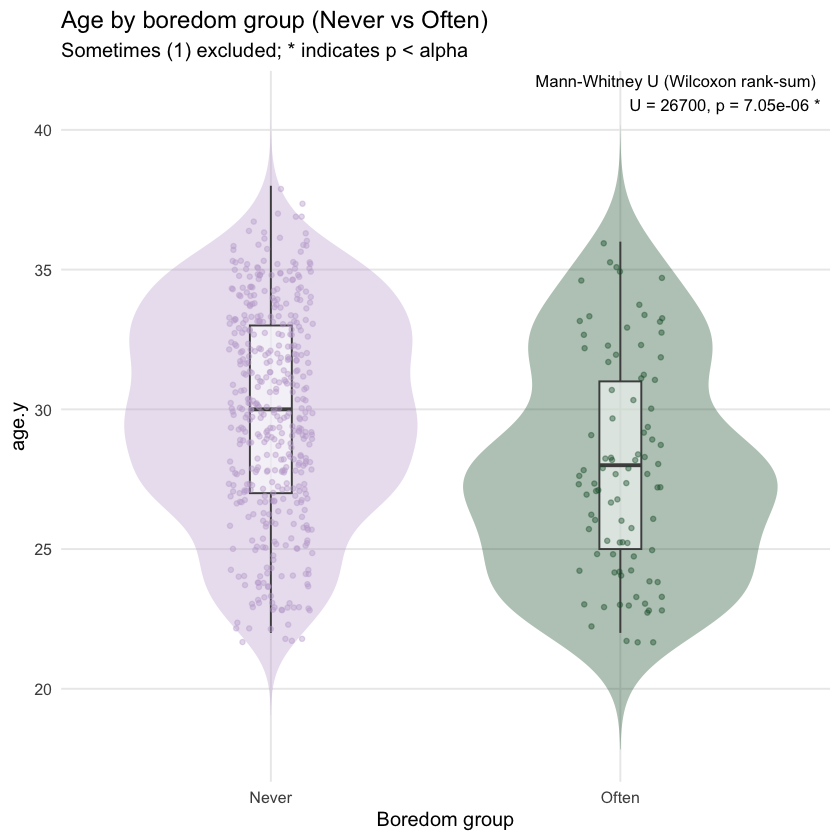

In [142]:
# =============================================================================
# 10. Age: Never (0) vs Often (2) — t-test or Mann-Whitney + violin plot
# =============================================================================

if (!exists("model_data")) {
  stop("Run sections 1–2 first so model_data is available.")
}
if (!exists("boredom_palette")) {
  stop("Run section 0 (setup) first so boredom_palette is defined.")
}

boredom_subset_levels_10 <- c(0, 2)
boredom_subset_labels_10 <- c("Never", "Often")
boredom_palette_10 <- boredom_palette[boredom_subset_labels_10]

if (!exists("age_covariate_name")) {
  age_covariate_name <- dplyr::case_when(
    "age" %in% names(model_data) ~ "age",
    "age.y" %in% names(model_data) ~ "age.y",
    "age.x" %in% names(model_data) ~ "age.x",
    TRUE ~ NA_character_
  )
}
if (is.na(age_covariate_name)) {
  stop("No age column found (checked: age, age.y, age.x).")
}
cat("Using age column:", age_covariate_name, "\n")

age_by_boredom_df <- model_data %>%
  dplyr::filter(boredom %in% boredom_subset_levels_10) %>%
  dplyr::select(subject_id, boredom, all_of(age_covariate_name)) %>%
  dplyr::rename(age = all_of(age_covariate_name)) %>%
  dplyr::filter(!is.na(age)) %>%
  dplyr::mutate(
    boredom_grp = factor(
      boredom,
      levels = boredom_subset_levels_10,
      labels = boredom_subset_labels_10
    )
  )

cat("\nSection 10 sample (boredom 0 & 2): N =", nrow(age_by_boredom_df), "\n")
print(table(age_by_boredom_df$boredom_grp))

age_never <- age_by_boredom_df$age[age_by_boredom_df$boredom == 0]
age_often <- age_by_boredom_df$age[age_by_boredom_df$boredom == 2]

if (length(age_never) < 2 || length(age_often) < 2) {
  stop("Need at least 2 subjects per boredom group for a two-sample test.")
}

# Choose test: Welch t-test if both groups pass Shapiro-Wilk; else Mann-Whitney U
use_welch_t <- FALSE
shapiro_p_never <- NA_real_
shapiro_p_often <- NA_real_

if (length(age_never) >= 3 && length(age_never) <= 5000 &&
    length(age_often) >= 3 && length(age_often) <= 5000) {
  shapiro_p_never <- stats::shapiro.test(age_never)$p.value
  shapiro_p_often <- stats::shapiro.test(age_often)$p.value
  use_welch_t <- shapiro_p_never > 0.05 && shapiro_p_often > 0.05
}

if (use_welch_t) {
  test_fit <- stats::t.test(age_never, age_often, var.equal = FALSE)
  test_name <- "Welch two-sample t-test"
  test_stat <- unname(test_fit$statistic)
  test_p <- test_fit$p.value
  mean_never <- mean(age_never)
  mean_often <- mean(age_often)
} else {
  test_fit <- stats::wilcox.test(
    age_never,
    age_often,
    alternative = "two.sided",
    exact = FALSE
  )
  test_name <- "Mann-Whitney U (Wilcoxon rank-sum)"
  test_stat <- unname(test_fit$statistic)
  test_p <- test_fit$p.value
  mean_never <- stats::median(age_never)
  mean_often <- stats::median(age_often)
}

age_group_test_results <- tibble::tibble(
  brain_measure_name = brain_measure_name,
  comparison = "boredom_0_vs_2",
  group_low = "Never (0)",
  group_high = "Often (2)",
  n_never = length(age_never),
  n_often = length(age_often),
  test_used = test_name,
  shapiro_p_never = shapiro_p_never,
  shapiro_p_often = shapiro_p_often,
  summary_never = mean_never,
  summary_often = mean_often,
  summary_type = if (use_welch_t) "mean" else "median",
  test_statistic = test_stat,
  p_value = test_p,
  significant = test_p < fdr_alpha
)

cat("\nAge group comparison (Never vs Often):\n")
print(age_group_test_results)

out_csv_age_groups <- file.path(
  paths$results_dir,
  paste0(
    "age_group_test_never_vs_often_",
    sanitize_label(brain_measure_name),
    ".csv"
  )
)
readr::write_csv(age_group_test_results, out_csv_age_groups)
cat("Saved:", out_csv_age_groups, "\n")

stat_label_10 <- paste0(
  test_name,
  "\n",
  if (use_welch_t) "t" else "U",
  " = ", signif(test_stat, 3),
  ", p = ", signif(test_p, 3),
  ifelse(test_p < fdr_alpha, " *", "")
)

fig_dir_age_groups <- file.path(
  paths$results_dir,
  "figures",
  sanitize_label(brain_measure_name),
  "never_vs_often",
  "age_by_boredom"
)
dir.create(fig_dir_age_groups, recursive = TRUE, showWarnings = FALSE)

p_age_violin <- ggplot2::ggplot(
  age_by_boredom_df,
  ggplot2::aes(
    x = boredom_grp,
    y = age,
    fill = boredom_grp,
    color = boredom_grp
  )
) +
  ggplot2::geom_violin(trim = FALSE, alpha = 0.35, color = NA) +
  ggplot2::geom_boxplot(
    width = 0.12,
    outlier.shape = NA,
    alpha = 0.55,
    fill = "white",
    color = "grey30"
  ) +
  ggplot2::geom_jitter(
    width = 0.12,
    alpha = 0.4,
    size = 1.1,
    show.legend = FALSE
  ) +
  ggplot2::scale_fill_manual(values = boredom_palette_10, name = "Boredom") +
  ggplot2::scale_color_manual(values = boredom_palette_10, guide = "none") +
  ggplot2::annotate(
    "text",
    x = Inf,
    y = Inf,
    label = stat_label_10,
    hjust = 1.05,
    vjust = 1.1,
    size = 3.5
  ) +
  ggplot2::labs(
    x = "Boredom group",
    y = age_covariate_name,
    title = "Age by boredom group (Never vs Often)",
    subtitle = "Sometimes (1) excluded; * indicates p < alpha"
  ) +
  ggplot2::theme_minimal(base_size = 12) +
  ggplot2::theme(
    panel.grid.minor = ggplot2::element_blank(),
    legend.position = "none"
  ) +
  ggplot2::coord_cartesian(clip = "off")

print(p_age_violin)

out_svg_age_violin <- file.path(
  fig_dir_age_groups,
  paste0(
    "violin_age_never_vs_often_",
    sanitize_label(brain_measure_name),
    ".svg"
  )
)
ggplot2::ggsave(out_svg_age_violin, plot = p_age_violin, width = 7, height = 5.5, dpi = 150)
cat("Saved plot:", out_svg_age_violin, "\n")


## 11. Logistic regression: boredom (Never vs Often) ~ age

Simple binary logistic regression on the **0 vs 2** boredom subset: predicts **Often (1)** vs **Never (0)** from age. Reports the age coefficient, odds ratio, and p-value.


=== Section 11: logistic regression (Often vs Never) ~ age ===
N = 544 

Never Often 
  453    91 

Model summary:

Call:
stats::glm(formula = boredom_y ~ age, family = stats::binomial(), 
    data = logistic_age_df)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  2.47947    0.90379   2.743  0.00608 ** 
age         -0.14153    0.03175  -4.457 8.31e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 491.28  on 543  degrees of freedom
Residual deviance: 470.28  on 542  degrees of freedom
AIC: 474.28

Number of Fisher Scoring iterations: 4


Age term (logistic regression):
# A tibble: 1 x 15
  brain_measure_name   comparison outcome_coding predictor     n n_never n_often
  <chr>                <chr>      <chr>          <chr>     <int>   <int>   <int>
1 functional_connecti~ boredom_0~ Often=1, Neve~ age.y       544     453      91
# i 8 more variables: esti

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


Saved plot: /Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/figures/functional_connectivity/never_vs_often/logistic_age/logistic_boredom_age_never_vs_often_functional_connectivity.svg 


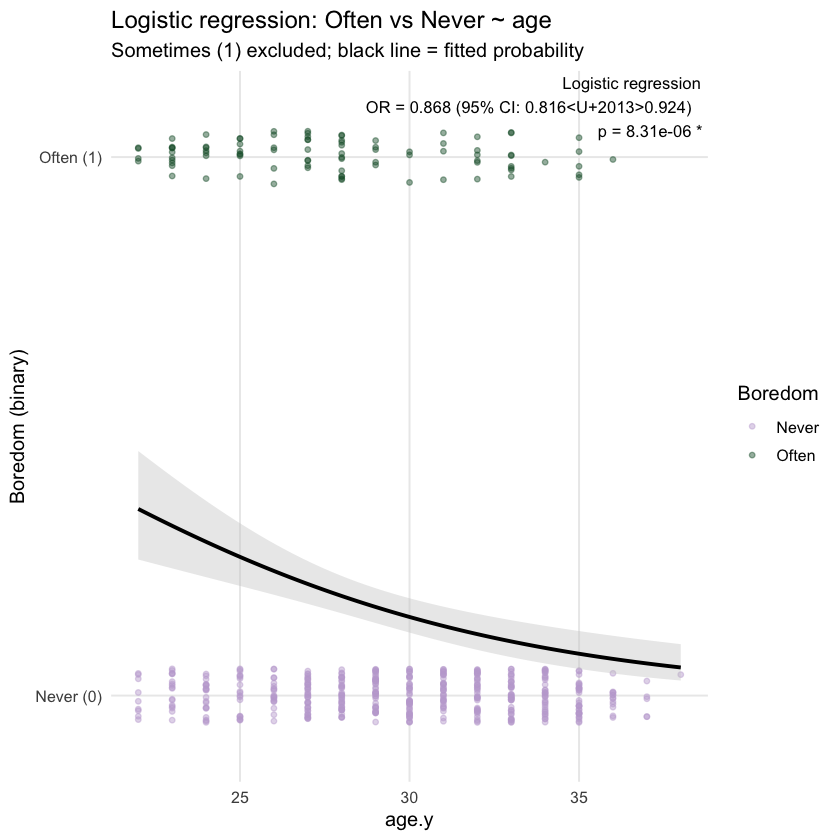

In [143]:
# =============================================================================
# 11. Logistic regression: boredom (0 vs 2) ~ age
# =============================================================================

if (!exists("model_data")) {
  stop("Run sections 1–2 first so model_data is available.")
}

if (!exists("age_covariate_name")) {
  age_covariate_name <- dplyr::case_when(
    "age" %in% names(model_data) ~ "age",
    "age.y" %in% names(model_data) ~ "age.y",
    "age.x" %in% names(model_data) ~ "age.x",
    TRUE ~ NA_character_
  )
}
if (is.na(age_covariate_name)) {
  stop("No age column found (checked: age, age.y, age.x).")
}

logistic_age_df <- model_data %>%
  dplyr::filter(boredom %in% c(0, 2)) %>%
  dplyr::select(subject_id, boredom, all_of(age_covariate_name)) %>%
  dplyr::rename(age = all_of(age_covariate_name)) %>%
  dplyr::filter(!is.na(age)) %>%
  dplyr::mutate(
    boredom_y = as.integer(boredom == 2),
    boredom_grp = factor(
      boredom,
      levels = c(0, 2),
      labels = c("Never", "Often")
    )
  )

cat("\n=== Section 11: logistic regression (Often vs Never) ~ age ===\n")
cat("N =", nrow(logistic_age_df), "\n")
print(table(logistic_age_df$boredom_grp))

logistic_age_fit <- stats::glm(
  boredom_y ~ age,
  data = logistic_age_df,
  family = stats::binomial()
)

cat("\nModel summary:\n")
print(summary(logistic_age_fit))

logistic_age_ct <- coef(summary(logistic_age_fit))
age_coef <- logistic_age_ct["age", "Estimate"]
age_se <- logistic_age_ct["age", "Std. Error"]
age_z <- logistic_age_ct["age", "z value"]
age_p <- logistic_age_ct["age", "Pr(>|z|)"]
age_or <- exp(age_coef)
age_or_ci_low <- exp(age_coef - 1.96 * age_se)
age_or_ci_high <- exp(age_coef + 1.96 * age_se)

logistic_age_results <- tibble::tibble(
  brain_measure_name = brain_measure_name,
  comparison = "boredom_0_vs_2",
  outcome_coding = "Often=1, Never=0",
  predictor = age_covariate_name,
  n = nrow(logistic_age_df),
  n_never = sum(logistic_age_df$boredom == 0),
  n_often = sum(logistic_age_df$boredom == 2),
  estimate_log_odds = age_coef,
  std_error = age_se,
  z_value = age_z,
  p_value = age_p,
  odds_ratio = age_or,
  or_ci_low = age_or_ci_low,
  or_ci_high = age_or_ci_high,
  significant = age_p < fdr_alpha
)

cat("\nAge term (logistic regression):\n")
print(logistic_age_results)

if (logistic_age_results$significant) {
  cat("\nAge is significantly associated with boredom (p <", fdr_alpha, ").\n")
} else {
  cat("\nAge is not significantly associated with boredom (p >=", fdr_alpha, ").\n")
}

out_csv_logistic_age <- file.path(
  paths$results_dir,
  paste0(
    "logistic_boredom_age_never_vs_often_",
    sanitize_label(brain_measure_name),
    ".csv"
  )
)
readr::write_csv(logistic_age_results, out_csv_logistic_age)
cat("\nSaved:", out_csv_logistic_age, "\n")

if (exists("boredom_palette")) {
  logistic_palette <- boredom_palette[c("Never", "Often")]

  stat_label_11 <- paste0(
    "Logistic regression\n",
    "OR = ", signif(age_or, 3),
    " (95% CI: ", signif(age_or_ci_low, 3), "–", signif(age_or_ci_high, 3), ")\n",
    "p = ", signif(age_p, 3),
    ifelse(age_p < fdr_alpha, " *", "")
  )

  fig_dir_logistic_age <- file.path(
    paths$results_dir,
    "figures",
    sanitize_label(brain_measure_name),
    "never_vs_often",
    "logistic_age"
  )
  dir.create(fig_dir_logistic_age, recursive = TRUE, showWarnings = FALSE)

  p_logistic_age <- ggplot2::ggplot(
    logistic_age_df,
    ggplot2::aes(x = age, y = boredom_y, color = boredom_grp)
  ) +
    ggplot2::geom_jitter(
      width = 0,
      height = 0.05,
      alpha = 0.45,
      size = 1.2
    ) +
    ggplot2::geom_smooth(
      method = "glm",
      method.args = list(family = stats::binomial()),
      se = TRUE,
      color = "black",
      fill = "grey80",
      inherit.aes = FALSE,
      mapping = ggplot2::aes(x = age, y = boredom_y)
    ) +
    ggplot2::annotate(
      "text",
      x = Inf,
      y = Inf,
      label = stat_label_11,
      hjust = 1.05,
      vjust = 1.1,
      size = 3.5
    ) +
    ggplot2::scale_color_manual(values = logistic_palette, name = "Boredom") +
    ggplot2::scale_y_continuous(
      breaks = c(0, 1),
      labels = c("Never (0)", "Often (1)"),
      limits = c(-0.1, 1.1)
    ) +
    ggplot2::labs(
      x = age_covariate_name,
      y = "Boredom (binary)",
      title = "Logistic regression: Often vs Never ~ age",
      subtitle = "Sometimes (1) excluded; black line = fitted probability"
    ) +
    ggplot2::theme_minimal(base_size = 12) +
    ggplot2::theme(panel.grid.minor = ggplot2::element_blank()) +
    ggplot2::coord_cartesian(clip = "off")

  print(p_logistic_age)

  out_svg_logistic_age <- file.path(
    fig_dir_logistic_age,
    paste0(
      "logistic_boredom_age_never_vs_often_",
      sanitize_label(brain_measure_name),
      ".svg"
    )
  )
  ggplot2::ggsave(
    out_svg_logistic_age,
    plot = p_logistic_age,
    width = 7,
    height = 5.5,
    dpi = 150
  )
  cat("Saved plot:", out_svg_logistic_age, "\n")
}


## 12. Multiple linear regression: brain ~ boredom + behavioural covariate (Never vs Often)

Subsets to **boredom = 0 (Never)** and **boredom = 2 (Often)** only (same as section 9; **Sometimes excluded**).

For each behavioural covariate in `covariate_models` (`DSM_Adh_T`, `ASR_Attn_T`, `DSM_Hype_Raw`), fits separate **multiple linear regression** models:

`brain_metric ~ boredom + covariate`

- **12a:** one model per ROI (502 ROIs); FDR across ROIs on the **boredom** coefficient (Often vs Never).
- **12b:** one model on global `roi_mean_all` (no ROI-level FDR).

Boredom is coded as a factor (reference = Never). Requires sections **0–2** (and section **1** for `brain_predictors`). Reuses `model_data_never_often` if section 9 was already run.


In [34]:
# =============================================================================
# 12. Multiple LM: brain ~ boredom + behavioural covariate (Never vs Often)
# =============================================================================

if (!exists("model_data")) {
  stop("Run sections 1–2 first so model_data is available.")
}

boredom_subset_tag <- "never_vs_often"
boredom_subset_levels <- c(0, 2)
boredom_subset_labels <- c("Never", "Often")

if (!exists("model_data_never_often")) {
  model_data_never_often <- model_data %>%
    dplyr::filter(boredom %in% boredom_subset_levels)
} else {
  model_data_never_often <- model_data_never_often %>%
    dplyr::filter(boredom %in% boredom_subset_levels)
}

cat("\n=== Section 12: brain ~ boredom + covariate (Never vs Often) ===\n")
cat("Subset N:", nrow(model_data_never_often), "\n")
print(table(model_data_never_often$boredom, useNA = "ifany"))

if (nrow(model_data_never_often) < 20) {
  stop("Too few subjects after filtering to boredom 0 and 2.")
}

boredom_term_pattern <- "^boredom"

extract_lm_all_coefs <- function(fit, brain_var, model_name, covariate, analysis_scope) {
  if (is.null(fit)) {
    return(tibble::tibble(
      brain_measure_name = brain_measure_name,
      boredom_subset = boredom_subset_tag,
      analysis_scope = analysis_scope,
      model = model_name,
      covariate = covariate,
      brain_var = brain_var,
      term = NA_character_,
      estimate = NA_real_,
      std_error = NA_real_,
      t_value = NA_real_,
      p_value = NA_real_,
      r_squared = NA_real_,
      adj_r_squared = NA_real_,
      residual_std_error = NA_real_,
      f_statistic = NA_real_,
      f_p_value = NA_real_,
      n_obs = NA_integer_
    ))
  }

  sm <- summary(fit)
  s <- sm$coefficients
  fstat <- sm$fstatistic
  n_coef <- nrow(s)

  tibble::tibble(
    brain_measure_name = brain_measure_name,
    boredom_subset = boredom_subset_tag,
    analysis_scope = analysis_scope,
    model = model_name,
    covariate = covariate,
    brain_var = brain_var,
    term = rownames(s),
    estimate = s[, "Estimate"],
    std_error = s[, "Std. Error"],
    t_value = s[, "t value"],
    p_value = s[, "Pr(>|t|)"],
    r_squared = rep(sm$r.squared, n_coef),
    adj_r_squared = rep(sm$adj.r.squared, n_coef),
    residual_std_error = rep(sm$sigma, n_coef),
    f_statistic = rep(if (!is.null(fstat)) unname(fstat[1]) else NA_real_, n_coef),
    f_p_value = rep(
      if (!is.null(fstat)) {
        stats::pf(unname(fstat[1]), unname(fstat[2]), unname(fstat[3]), lower.tail = FALSE)
      } else {
        NA_real_
      },
      n_coef
    ),
    n_obs = rep(as.integer(stats::nobs(fit)), n_coef)
  )
}

run_lm_brain_ancova_batch <- function(
    model_name,
    covariate,
    data,
    brain_vars,
    analysis_scope = "per_roi",
    apply_fdr = TRUE
) {
  brain_vars <- as.character(brain_vars)
  preds <- unique(c(brain_vars, "boredom", covariate, "subject_id"))
  missing_preds <- setdiff(preds, names(data))
  if (length(missing_preds) > 0) {
    stop(
      "Missing columns for LM ancova (", model_name, "): ",
      paste(missing_preds, collapse = ", ")
    )
  }

  data_clean <- data %>%
    dplyr::select(all_of(preds)) %>%
    tidyr::drop_na() %>%
    dplyr::mutate(
      boredom = factor(
        boredom,
        levels = boredom_subset_levels,
        labels = boredom_subset_labels
      )
    )

  cat("\n--- MLR:", "brain ~ boredom +", covariate, "|", model_name, "|", analysis_scope, "---\n")
  cat("Brain outcome(s):", length(brain_vars), "ROI(s)\n")
  cat("Formula: brain_var ~ boredom +", covariate, "\n")
  cat("Final sample size:", nrow(data_clean), "\n")
  print(table(data_clean$boredom))

  batch_results <- purrr::map_dfr(brain_vars, function(brain_var) {
    fml <- stats::as.formula(paste(brain_var, "~ boredom +", covariate))
    fit <- tryCatch(
      stats::lm(fml, data = data_clean),
      error = function(e) {
        warning("LM failed for ", brain_var, ": ", conditionMessage(e))
        NULL
      }
    )

    extract_lm_all_coefs(
      fit, brain_var, model_name, covariate, analysis_scope
    )
  })

  if (apply_fdr && nrow(batch_results) > 1) {
    batch_results <- batch_results %>%
      dplyr::group_by(term) %>%
      dplyr::mutate(
        p_fdr = dplyr::if_else(
          grepl(boredom_term_pattern, term),
          p.adjust(p_value, method = "fdr"),
          NA_real_
        ),
        significant_fdr = !is.na(p_fdr) & p_fdr < fdr_alpha
      ) %>%
      dplyr::ungroup()
    n_sig <- sum(
      batch_results$significant_fdr & grepl(boredom_term_pattern, batch_results$term),
      na.rm = TRUE
    )
    cat("FDR-significant boredom terms (q <", fdr_alpha, "):", n_sig, "\n")
  } else {
    batch_results <- batch_results %>%
      dplyr::mutate(
        p_fdr = NA_real_,
        significant_fdr = !is.na(p_value) & p_value < fdr_alpha
      )
    cat("Uncorrected significant terms (p <", fdr_alpha, "):",
        sum(batch_results$significant_fdr, na.rm = TRUE), "\n")
    if (!apply_fdr) {
      cat("(FDR not applied: single global-average outcome)\n")
    }
  }

  list(data = data_clean, results = batch_results)
}

lm_ancova_roi_results <- list()

for (model_name in names(covariate_models)) {
  covariate <- covariate_models[[model_name]][[1]]
  batch <- run_lm_brain_ancova_batch(
    model_name = model_name,
    covariate = covariate,
    data = model_data_never_often,
    brain_vars = brain_predictors,
    analysis_scope = "per_roi",
    apply_fdr = TRUE
  )
  lm_ancova_roi_results[[model_name]] <- batch

  example_fit <- stats::lm(
    stats::as.formula(
      paste(brain_predictors[[1]], "~ boredom +", covariate)
    ),
    data = batch$data
  )
  cat("\nExample MLR (Never vs Often): ", brain_predictors[[1]], " ~ boredom + ", covariate, "\n", sep = "")
  print(summary(example_fit))
}

lm_ancova_roi_table <- dplyr::bind_rows(
  lapply(lm_ancova_roi_results, `[[`, "results")
)

out_lm_ancova_roi <- file.path(
  paths$results_dir,
  paste0(
    "lm_brain_ancova_",
    sanitize_label(brain_measure_name),
    "_",
    boredom_subset_tag,
    "_502roi_fdr.csv"
  )
)
readr::write_csv(lm_ancova_roi_table, out_lm_ancova_roi)
cat("\nSaved per-ROI MLR results (Never vs Often):\n", out_lm_ancova_roi, "\n", sep = "")

cat("\nFDR-significant boredom coefficients (q <", fdr_alpha, ") by model:\n")
lm_ancova_roi_table %>%
  dplyr::filter(grepl(boredom_term_pattern, term), significant_fdr) %>%
  dplyr::arrange(model, p_fdr) %>%
  print(n = Inf)

# --- 12b. Global mean (roi_mean_all) ---
lm_ancova_global_results <- list()

for (model_name in names(covariate_models)) {
  covariate <- covariate_models[[model_name]][[1]]
  batch <- run_lm_brain_ancova_batch(
    model_name = model_name,
    covariate = covariate,
    data = model_data_never_often,
    brain_vars = brain_global_var,
    analysis_scope = "roi_mean_global",
    apply_fdr = FALSE
  )
  lm_ancova_global_results[[model_name]] <- batch
}

lm_ancova_global_table <- dplyr::bind_rows(
  lapply(lm_ancova_global_results, `[[`, "results")
)

out_lm_ancova_global <- file.path(
  paths$results_dir,
  paste0(
    "lm_brain_ancova_",
    sanitize_label(brain_measure_name),
    "_",
    boredom_subset_tag,
    "_roi_mean_global.csv"
  )
)
readr::write_csv(lm_ancova_global_table, out_lm_ancova_global)
cat("\nSaved global-mean MLR results (Never vs Often):\n", out_lm_ancova_global, "\n", sep = "")

cat("\nGlobal roi_mean_all models (brain ~ boredom + covariate):\n")
print(lm_ancova_global_table)



=== Section 12: brain ~ boredom + covariate (Never vs Often) ===
Subset N: 544 

  0   2 
453  91 

--- MLR: brain ~ boredom + DSM_Adh_T | DSM_Adh_T | per_roi ---
Brain outcome(s): 502 ROI(s)
Formula: brain_var ~ boredom + DSM_Adh_T 
Final sample size: 544 

Never Often 
  453    91 
FDR-significant boredom terms (q < 0.05 ): 0 

Example MLR (Never vs Often): roi_1 ~ boredom + DSM_Adh_T

Call:
stats::lm(formula = stats::as.formula(paste(brain_predictors[[1]], 
    "~ boredom +", covariate)), data = batch$data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.212573 -0.082667 -0.003215  0.079457  0.273571 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   0.2631927  0.0473173   5.562 4.19e-08 ***
boredomOften  0.0262759  0.0135451   1.940   0.0529 .  
DSM_Adh_T    -0.0005655  0.0008885  -0.636   0.5247    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.1047 on 541 degrees of freedom
Mult

## 13. Clinical cutoff and median splits (Never vs Often)

Using **Never (0)** and **Often (2)** subjects only, this section:

- Creates clinical cutoff groups for `DSM_Adh_T`, `ASR_Attn_T`, and `DSM_Hype_Raw` (`Clinical` if score >= 60; otherwise `Non-Clinical`).
- Calculates medians for all three variables and creates median-split groups (`High` if score >= median; otherwise `Low`).
- Builds a subject-level split dataframe containing `subject_id`, boredom score/group, and split group assignments for each variable.
- Prints exact counts for split groups and boredom-by-group cross-tab counts.
- Produces clean `ggplot2` bar plots for clinical and median splits.



=== Section 13: Split summaries for Never vs Often ===
N subjects in subset: 544 
Boredom group counts:

Never Often 
  453    91 

Clinical cutoff counts (overall):
# A tibble: 5 x 3
  variable     clinical_group     n
  <chr>        <fct>          <int>
1 ASR_Attn_T   Non-Clinical     464
2 ASR_Attn_T   Clinical          80
3 DSM_Adh_T    Non-Clinical     457
4 DSM_Adh_T    Clinical          87
5 DSM_Hype_Raw Non-Clinical     544

Clinical cutoff counts by boredom group:
# A tibble: 10 x 4
   variable     boredom_group clinical_group     n
   <chr>        <fct>         <fct>          <int>
 1 ASR_Attn_T   Never         Non-Clinical     409
 2 ASR_Attn_T   Never         Clinical          44
 3 ASR_Attn_T   Often         Non-Clinical      55
 4 ASR_Attn_T   Often         Clinical          36
 5 DSM_Adh_T    Never         Non-Clinical     413
 6 DSM_Adh_T    Never         Clinical          40
 7 DSM_Adh_T    Often         Non-Clinical      44
 8 DSM_Adh_T    Often         Clinical     

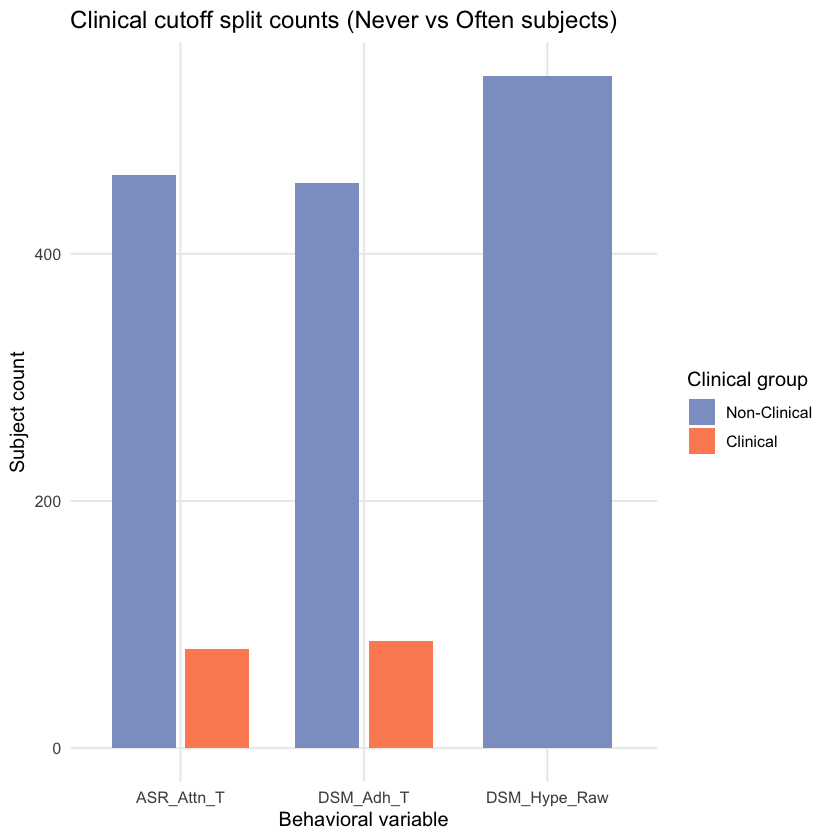


Created dataframe: section13_split_df
Rows: 544 | Cols: 12 
# A tibble: 6 x 12
  subject_id boredom boredom_group DSM_Adh_T ASR_Attn_T DSM_Hype_Raw
  <chr>        <dbl> <fct>             <dbl>      <dbl>        <dbl>
1 100307           0 Never                51         50            3
2 100408           0 Never                51         55            1
3 100610           0 Never                50         52            0
4 101006           0 Never                50         50            2
5 101915           0 Never                50         50            2
6 102311           0 Never                50         50            1
# i 6 more variables: DSM_Adh_T_clinical <fct>, ASR_Attn_T_clinical <fct>,
#   DSM_Hype_Raw_clinical <fct>, DSM_Adh_T_median <fct>,
#   ASR_Attn_T_median <fct>, DSM_Hype_Raw_median <fct>


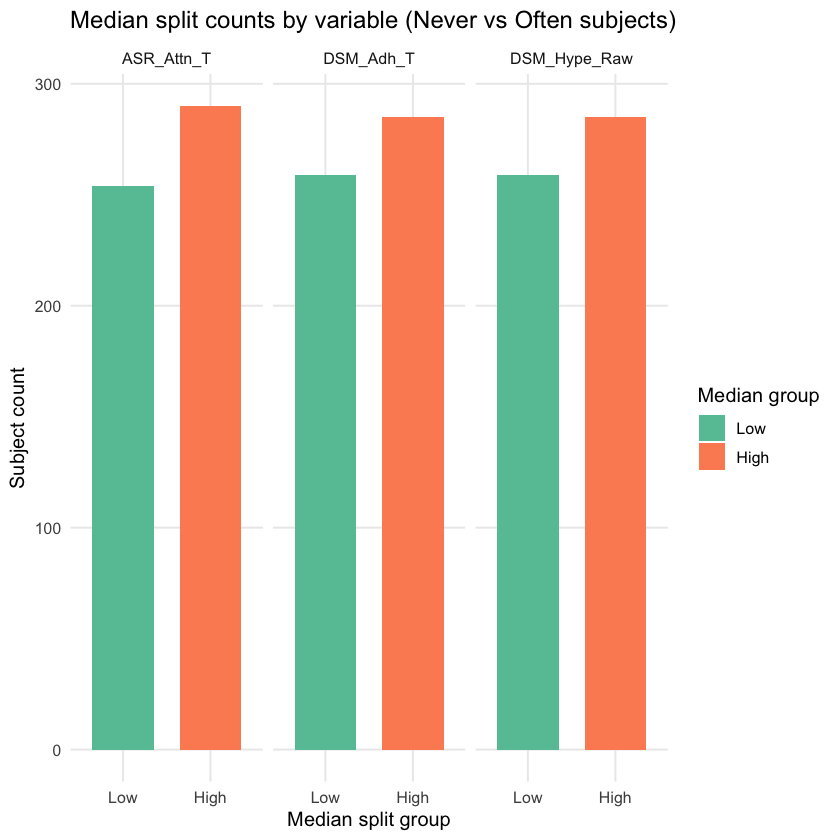

In [21]:
# =============================================================================
# 13. Clinical cutoff + median split groupings (Never vs Often)
# =============================================================================

if (!exists("model_data")) {
  stop("Run sections 1-2 first so model_data is available.")
}

split_vars <- c("DSM_Adh_T", "ASR_Attn_T", "DSM_Hype_Raw")
missing_split_vars <- setdiff(split_vars, names(model_data))
if (length(missing_split_vars) > 0) {
  stop("Missing required columns for section 13: ", paste(missing_split_vars, collapse = ", "))
}

boredom_subset_levels <- c(0, 2)
boredom_subset_labels <- c("Never", "Often")

if (!exists("model_data_never_often")) {
  model_data_never_often <- model_data %>%
    dplyr::filter(boredom %in% boredom_subset_levels)
}

section13_data <- model_data_never_often %>%
  dplyr::filter(boredom %in% boredom_subset_levels) %>%
  dplyr::mutate(
    boredom_group = factor(
      boredom,
      levels = boredom_subset_levels,
      labels = boredom_subset_labels
    )
  )

cat("\n=== Section 13: Split summaries for Never vs Often ===\n")
cat("N subjects in subset:", nrow(section13_data), "\n")
cat("Boredom group counts:\n")
print(table(section13_data$boredom_group, useNA = "ifany"))

# 1) Clinical cutoff split (>= 60 clinical)
section13_data <- section13_data %>%
  dplyr::mutate(
    DSM_Adh_T_clinical = ifelse(DSM_Adh_T >= 60, "Clinical", "Non-Clinical"),
    ASR_Attn_T_clinical = ifelse(ASR_Attn_T >= 60, "Clinical", "Non-Clinical"),
    DSM_Hype_Raw_clinical = ifelse(DSM_Hype_Raw >= 60, "Clinical", "Non-Clinical")
  ) %>%
  dplyr::mutate(
    dplyr::across(
      .cols = dplyr::ends_with("_clinical"),
      .fns = ~ factor(.x, levels = c("Non-Clinical", "Clinical"))
    )
  )

cat("\nClinical cutoff counts (overall):\n")
clinical_counts <- section13_data %>%
  dplyr::select(dplyr::ends_with("_clinical")) %>%
  tidyr::pivot_longer(
    cols = dplyr::everything(),
    names_to = "variable",
    values_to = "clinical_group"
  ) %>%
  dplyr::mutate(variable = gsub("_clinical$", "", variable)) %>%
  dplyr::count(variable, clinical_group, name = "n")
print(clinical_counts, n = Inf)

cat("\nClinical cutoff counts by boredom group:\n")
clinical_by_boredom <- section13_data %>%
  dplyr::select(boredom_group, dplyr::ends_with("_clinical")) %>%
  tidyr::pivot_longer(
    cols = -boredom_group,
    names_to = "variable",
    values_to = "clinical_group"
  ) %>%
  dplyr::mutate(variable = gsub("_clinical$", "", variable)) %>%
  dplyr::count(variable, boredom_group, clinical_group, name = "n") %>%
  dplyr::arrange(variable, boredom_group, clinical_group)
print(clinical_by_boredom, n = Inf)

clinical_plot <- clinical_counts %>%
  ggplot2::ggplot(
    ggplot2::aes(x = variable, y = n, fill = clinical_group)
  ) +
  ggplot2::geom_col(position = ggplot2::position_dodge(width = 0.8), width = 0.7) +
  ggplot2::scale_fill_manual(values = c("Non-Clinical" = "#8DA0CB", "Clinical" = "#FC8D62")) +
  ggplot2::labs(
    title = "Clinical cutoff split counts (Never vs Often subjects)",
    x = "Behavioral variable",
    y = "Subject count",
    fill = "Clinical group"
  ) +
  ggplot2::theme_minimal(base_size = 12) +
  ggplot2::theme(panel.grid.minor = ggplot2::element_blank())

print(clinical_plot)

# 2) Median split
medians <- section13_data %>%
  dplyr::summarise(
    dplyr::across(
      .cols = dplyr::all_of(split_vars),
      .fns = ~ median(.x, na.rm = TRUE)
    )
  )

cat("\nMedians (Never vs Often subset):\n")
print(medians)

med_dsm_adh <- medians$DSM_Adh_T[[1]]
med_asr_attn <- medians$ASR_Attn_T[[1]]
med_dsm_hype <- medians$DSM_Hype_Raw[[1]]

section13_data <- section13_data %>%
  dplyr::mutate(
    DSM_Adh_T_median = ifelse(DSM_Adh_T >= med_dsm_adh, "High", "Low"),
    ASR_Attn_T_median = ifelse(ASR_Attn_T >= med_asr_attn, "High", "Low"),
    DSM_Hype_Raw_median = ifelse(DSM_Hype_Raw >= med_dsm_hype, "High", "Low")
  ) %>%
  dplyr::mutate(
    dplyr::across(
      .cols = dplyr::ends_with("_median"),
      .fns = ~ factor(.x, levels = c("Low", "High"))
    )
  )

cat("\nMedian split counts (overall):\n")
median_counts <- section13_data %>%
  dplyr::select(dplyr::ends_with("_median")) %>%
  tidyr::pivot_longer(
    cols = dplyr::everything(),
    names_to = "variable",
    values_to = "median_group"
  ) %>%
  dplyr::mutate(variable = gsub("_median$", "", variable)) %>%
  dplyr::count(variable, median_group, name = "n")
print(median_counts, n = Inf)

cat("\nMedian split counts by boredom group:\n")
median_by_boredom <- section13_data %>%
  dplyr::select(boredom_group, dplyr::ends_with("_median")) %>%
  tidyr::pivot_longer(
    cols = -boredom_group,
    names_to = "variable",
    values_to = "median_group"
  ) %>%
  dplyr::mutate(variable = gsub("_median$", "", variable)) %>%
  dplyr::count(variable, boredom_group, median_group, name = "n") %>%
  dplyr::arrange(variable, boredom_group, median_group)
print(median_by_boredom, n = Inf)

median_plot <- median_counts %>%
  ggplot2::ggplot(
    ggplot2::aes(x = median_group, y = n, fill = median_group)
  ) +
  ggplot2::geom_col(width = 0.7) +
  ggplot2::facet_wrap(~ variable, nrow = 1) +
  ggplot2::scale_fill_manual(values = c("Low" = "#66C2A5", "High" = "#FC8D62")) +
  ggplot2::labs(
    title = "Median split counts by variable (Never vs Often subjects)",
    x = "Median split group",
    y = "Subject count",
    fill = "Median group"
  ) +
  ggplot2::theme_minimal(base_size = 12) +
  ggplot2::theme(panel.grid.minor = ggplot2::element_blank())

print(median_plot)

# Subject-level dataframe requested for downstream use
section13_split_df <- section13_data %>%
  dplyr::select(
    subject_id,
    boredom,
    boredom_group,
    dplyr::all_of(split_vars),
    DSM_Adh_T_clinical,
    ASR_Attn_T_clinical,
    DSM_Hype_Raw_clinical,
    DSM_Adh_T_median,
    ASR_Attn_T_median,
    DSM_Hype_Raw_median
  )

cat("\nCreated dataframe: section13_split_df\n")
cat("Rows:", nrow(section13_split_df), "| Cols:", ncol(section13_split_df), "\n")
print(utils::head(section13_split_df))



In [25]:
head(section13_split_df)

subject_id,boredom,boredom_group,DSM_Adh_T,ASR_Attn_T,DSM_Hype_Raw,DSM_Adh_T_clinical,ASR_Attn_T_clinical,DSM_Hype_Raw_clinical,DSM_Adh_T_median,ASR_Attn_T_median,DSM_Hype_Raw_median
<chr>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
100307,0,Never,51,50,3,Non-Clinical,Non-Clinical,Non-Clinical,Low,Low,High
100408,0,Never,51,55,1,Non-Clinical,Non-Clinical,Non-Clinical,Low,High,Low
100610,0,Never,50,52,0,Non-Clinical,Non-Clinical,Non-Clinical,Low,High,Low
101006,0,Never,50,50,2,Non-Clinical,Non-Clinical,Non-Clinical,Low,Low,High
101915,0,Never,50,50,2,Non-Clinical,Non-Clinical,Non-Clinical,Low,Low,High
102311,0,Never,50,50,1,Non-Clinical,Non-Clinical,Non-Clinical,Low,Low,Low


## 14. Compact clinical binary dataframe (DSM_Adh_T and ASR_Attn_T)


In [24]:
# =============================================================================
# 14. Compact clinical binary dataframe (DSM_Adh_T and ASR_Attn_T)
# =============================================================================

if (!exists("section13_split_df")) {
  stop("Run section 13 first so section13_split_df is available.")
}

section14_clinical_binary_df <- section13_split_df %>%
  dplyr::transmute(
    subject_id,
    boredom,
    DSM_Adh_T,
    DSM_Adh_T_clinical_binary = dplyr::if_else(DSM_Adh_T_clinical == "Clinical", 1L, 0L),
    ASR_Attn_T,
    ASR_Attn_T_clinical_binary = dplyr::if_else(ASR_Attn_T_clinical == "Clinical", 1L, 0L)
  )

cat("\nCreated dataframe: section14_clinical_binary_df\n")
cat("Rows:", nrow(section14_clinical_binary_df), "| Cols:", ncol(section14_clinical_binary_df), "\n")
print(utils::head(section14_clinical_binary_df))

cat("\nDSM_Adh_T clinical binary counts (0=low, 1=high):\n")
print(table(section14_clinical_binary_df$DSM_Adh_T_clinical_binary, useNA = "ifany"))

cat("\nASR_Attn_T clinical binary counts (0=low, 1=high):\n")
print(table(section14_clinical_binary_df$ASR_Attn_T_clinical_binary, useNA = "ifany"))

# save the output
out_csv_clinical_binary <- file.path(
  paths$results_dir,
  paste0(
    "clinical_behavioral_binary_df_never_vs_often_",
    sanitize_label(brain_measure_name),
    ".csv"
  )
)
readr::write_csv(section14_clinical_binary_df, out_csv_clinical_binary)
cat("\nSaved:", out_csv_clinical_binary, "\n", sep = "")


Created dataframe: section14_clinical_binary_df
Rows: 544 | Cols: 6 
# A tibble: 6 x 6
  subject_id boredom DSM_Adh_T DSM_Adh_T_clinical_binary ASR_Attn_T
  <chr>        <dbl>     <dbl>                     <int>      <dbl>
1 100307           0        51                         0         50
2 100408           0        51                         0         55
3 100610           0        50                         0         52
4 101006           0        50                         0         50
5 101915           0        50                         0         50
6 102311           0        50                         0         50
# i 1 more variable: ASR_Attn_T_clinical_binary <int>

DSM_Adh_T clinical binary counts (0=low, 1=high):

  0   1 
457  87 

ASR_Attn_T clinical binary counts (0=low, 1=high):

  0   1 
464  80 

Saved:/Users/ntaylor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/PhD/7. Boredom- Danckert/HCP_boredom_backup/model/ordinal_boredom/clinical_behavioral_binary